In [1]:
!pip install kaggle -q

from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Dataset'i indir
!kaggle datasets download -d bhushandivekar/video-game-sales-and-industry-data-1980-2024
!kaggle datasets download -d thedevastator/video-game-sales-and-ratings
!kaggle datasets download -d anandshaw2001/video-game-sales

#zip dosyaları aç
import zipfile

zip_files = [
    "video-game-sales-and-industry-data-1980-2024.zip",
    "video-game-sales-and-ratings.zip",
    "video-game-sales.zip"
]

for zip_name in zip_files:
    folder_name = zip_name.replace(".zip", "")
    os.makedirs(folder_name, exist_ok=True)
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(folder_name)

print("Zip dosyalari acildi.")

#hangi dosyalar geldi
print("Klasor icerigi:")
for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

#datasetleri oku
import pandas as pd

df1 = pd.read_csv("video-game-sales/vgsales.csv")
df2 = pd.read_csv("video-game-sales-and-ratings/Video_Games.csv")
df3 = pd.read_csv("video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv")

print("df1:", df1.shape)
print("df2:", df2.shape)
print("df3:", df3.shape)

df1.head()

#sütun adlarını oku
print(df1.columns)
print(df2.columns)
print(df3.columns)

#dataset1 userscore ve criticscore yok
df1 = df1.rename(columns={
    'Name': 'name',
    'Platform': 'platform',
    'Year': 'year',
    'Genre': 'genre',
    'Publisher': 'publisher',
    'Global_Sales': 'global_sales',
    'JP_Sales':'jp_sales',
    'NA_Sales':'na_sales',
    'EU_Sales':'eu_sales'
})

df1['critic_score'] = pd.NA
df1['user_score'] = pd.NA

df1 = df1[['name', 'platform', 'year', 'genre', 'publisher', 'critic_score', 'user_score', 'jp_sales', 'na_sales', 'eu_sales', 'global_sales']]

#dataset2, tam veri
df2 = df2.rename(columns={
    'Name': 'name',
    'Platform': 'platform',
    'Year_of_Release': 'year',
    'Genre': 'genre',
    'Publisher': 'publisher',
    'Global_Sales': 'global_sales',
    'JP_Sales':'jp_sales',
    'NA_Sales':'na_sales',
    'EU_Sales':'eu_sales',
    'Critic_Score': 'critic_score',
    'User_Score': 'user_score'
})

df2 = df2[['name', 'platform', 'year', 'genre', 'publisher', 'critic_score', 'user_score', 'jp_sales', 'na_sales', 'eu_sales', 'global_sales']]

#dataset3 userscore yok
df3 = df3.rename(columns={
    'title': 'name',
    'console': 'platform',
    'release_date': 'year',
    'genre': 'genre',
    'publisher': 'publisher',
    'total_sales': 'global_sales',
    'jp_sales':'jp_sales',
    'na_sales':'na_sales',
    'critic_score': 'critic_score'
})

df3['eu_sales'] = pd.NA
df3['user_score'] = pd.NA


df3 = df3[['name', 'platform', 'year', 'genre', 'publisher', 'critic_score', 'user_score', 'jp_sales', 'na_sales', 'eu_sales', 'global_sales']]





Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024
License(s): CC0-1.0
100% 2.32M/2.32M [00:00<00:00, 191MB/s]

Dataset URL: https://www.kaggle.com/datasets/thedevastator/video-game-sales-and-ratings
License(s): other
100% 540k/540k [00:00<00:00, 155MB/s]

Dataset URL: https://www.kaggle.com/datasets/anandshaw2001/video-game-sales
License(s): CC0-1.0
100% 381k/381k [00:00<00:00, 69.8MB/s]

Zip dosyalari acildi.
Klasor icerigi:
./video-game-sales.zip
./video-game-sales-and-industry-data-1980-2024.zip
./video-game-sales-and-ratings.zip
./.config/default_configs.db
./.config/.last_update_check.json
./.config/.last_survey_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/active_config
./.config/.last_opt_in_prompt.yaml
./.config/gce
./.config/config_sentinel
./.config/configurations/config_default
./.config/logs/2026.05.12/13.29.40.400999.log
./.config/logs/2

In [2]:

final_df = pd.concat([df1, df2, df3], ignore_index=True)

/tmp/ipykernel_14919/705220216.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([df1, df2, df3], ignore_index=True)


In [3]:

dup_rows = final_df[
    final_df.duplicated(
        subset=['name', 'platform', 'year', 'genre', 'publisher', 'critic_score', 'user_score', 'jp_sales', 'na_sales', 'eu_sales', 'global_sales'],
        keep=False
    )
]

dup_rows


,name,platform,year,genre,publisher,critic_score,user_score,jp_sales,na_sales,eu_sales,global_sales
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,NaN,NaN,6.81,29.08,3.58,40.24
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,NaN,NaN,10.22,11.27,8.89,31.37
5,Tetris,GB,1989.0,Puzzle,Nintendo,NaN,NaN,4.22,23.20,2.26,30.26
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,NaN,NaN,0.28,26.93,0.63,28.31
12,Pokemon Gold/Pokemon Silver,GB,1999.0,Role-Playing,Nintendo,NaN,NaN,7.20,9.00,6.18,23.10
...,...,...,...,...,...,...,...,...,...,...,...
93692,The Aquatic Games starring James Pond and the ...,GEN,01-01-1993,Sports,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN
94698,Z,PC,31-07-1996,Strategy,Virgin Interactive,NaN,NaN,NaN,NaN,NaN,NaN
94937,Battlezone II: Combat Commander,PC,31-12-1999,Strategy,Activision,NaN,NaN,NaN,NaN,NaN,NaN
94938,Battlezone II: Combat Commander,PC,31-12-1999,Strategy,Activision,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
final_df['eu_sales'].isna().sum()

np.int64(64016)

In [5]:
final_df['eu_sales'].notna().sum()

np.int64(33526)

In [6]:
import pandas as pd
import numpy as np

# Year sütununu temizleme
numeric_year = pd.to_numeric(final_df['year'], errors='coerce')

date_year = pd.to_datetime(
    final_df['year'],
    errors='coerce',
    dayfirst=True
).dt.year

# Eğer değer zaten 1980-2026 arasında sayıysa onu kullan,
# değilse tarih formatından gelen yılı kullan
final_df['year'] = numeric_year.where(
    numeric_year.between(1980, 2026),
    date_year
)

# Geçersiz yılları boş yap
final_df.loc[~final_df['year'].between(1980, 2026), 'year'] = np.nan

# Year boş olanları sil
final_df = final_df.dropna(subset=['year'])

# Yılı tam sayı yap
final_df['year'] = final_df['year'].astype(int)

In [7]:
print("Satır sayısı:", final_df.shape)
print("EU dolu satır:", final_df['eu_sales'].notna().sum())
print("EU boş satır:", final_df['eu_sales'].isna().sum())

Satır sayısı: (89880, 11)
EU dolu satır: 32982
EU boş satır: 56898


In [8]:
print(final_df[['year']].sample(20))

       year
87270  1997
14177  2006
58844  2017
26165  2007
54508  2014
89593  2012
3649   2001
72959  2018
17720  2002
93191  1999
68099  2014
33943  2010
38044  2000
25589  2007
43145  1995
70003  2013
32682  2006
67288  2004
21292  2007
81039  2012


In [9]:
import numpy as np
import pandas as pd


# 2. KARMAŞAYI ÇÖZEN KISIM:
# Sütunlarda string olarak yazılmış 'None', 'null' veya manuel eklediğin None'ları
# gerçek np.nan (Not a Number) formatına çekiyoruz.
bosluk_varyasyonlari = ['None', 'none', 'null', 'NULL', 'nan', 'NaN', ' ', 'N/A']
final_df.replace(bosluk_varyasyonlari, np.nan, inplace=True)
# Veri setinden rastgele 20 örnek çeker
final_df.sample(20)

,name,platform,year,genre,publisher,critic_score,user_score,jp_sales,na_sales,eu_sales,global_sales
45767,Dance Dance Revolution: Mario Mix (JP sales),GC,2005,Simulation,Nintendo,7.5,NaN,0.05,NaN,NaN,0.06
35346,Pictionary,Wii,2010,Misc,THQ,NaN,NaN,NaN,0.60,NaN,0.86
86788,Galaxy Force,MS,1989,Shooter,Activision,NaN,NaN,NaN,NaN,NaN,NaN
29175,Disney's Kim Possible: Global Gemini,DS,2007,Platform,Disney Interactive Studios,70.0,tbd,0.00,0.05,0.01,0.06
5334,Rally Cross 2,PS,1998,Racing,989 Studios,NaN,NaN,0.00,0.19,0.13,0.35
22599,Jeremy McGrath Supercross 2000,N64,1999,Racing,Acclaim Entertainment,NaN,NaN,0.00,0.23,0.06,0.29
55410,Privateer 2: The Darkening,PC,1996,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN
28193,Far Cry Vengeance,Wii,2006,Shooter,Ubisoft,38.0,5.3,0.00,0.06,0.01,0.08
67528,Donkey Konga 3: Tabe-houdai! Haru Mogitate 50 ...,GC,2005,Misc,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN
42257,Pro Cycling Manager 2016,PS4,2016,Sports,Focus Home Interactive,NaN,NaN,NaN,NaN,NaN,0.14


In [10]:
final_df = final_df.dropna(subset=['global_sales'])

In [11]:
final_df.shape

(51803, 11)

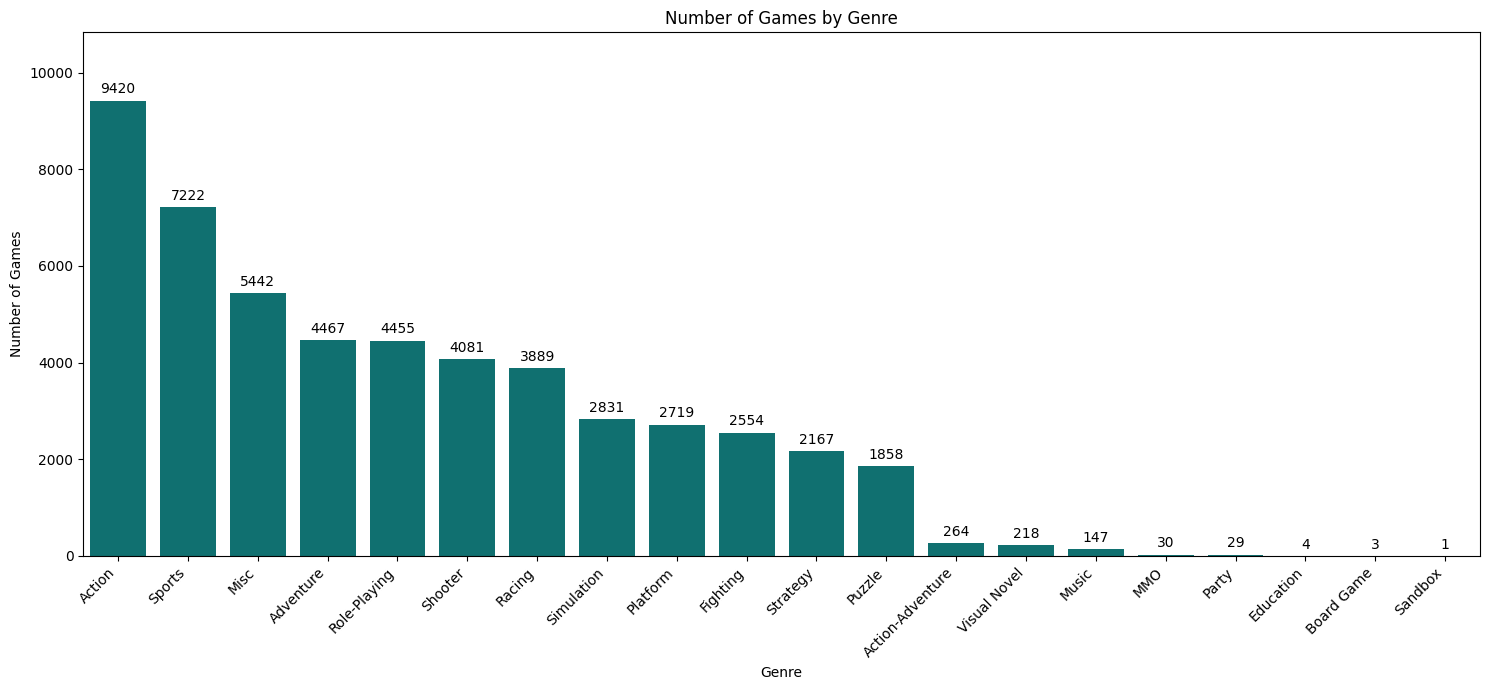

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = final_df['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

# Azalan sıraya göre sıralama
genre_counts = genre_counts.sort_values(by='count', ascending=False)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=genre_counts,
    x='genre',
    y='count',
    color='teal'
)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, genre_counts['count'].max() * 1.15)

plt.xticks(rotation=45, ha='right')
plt.title("Number of Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

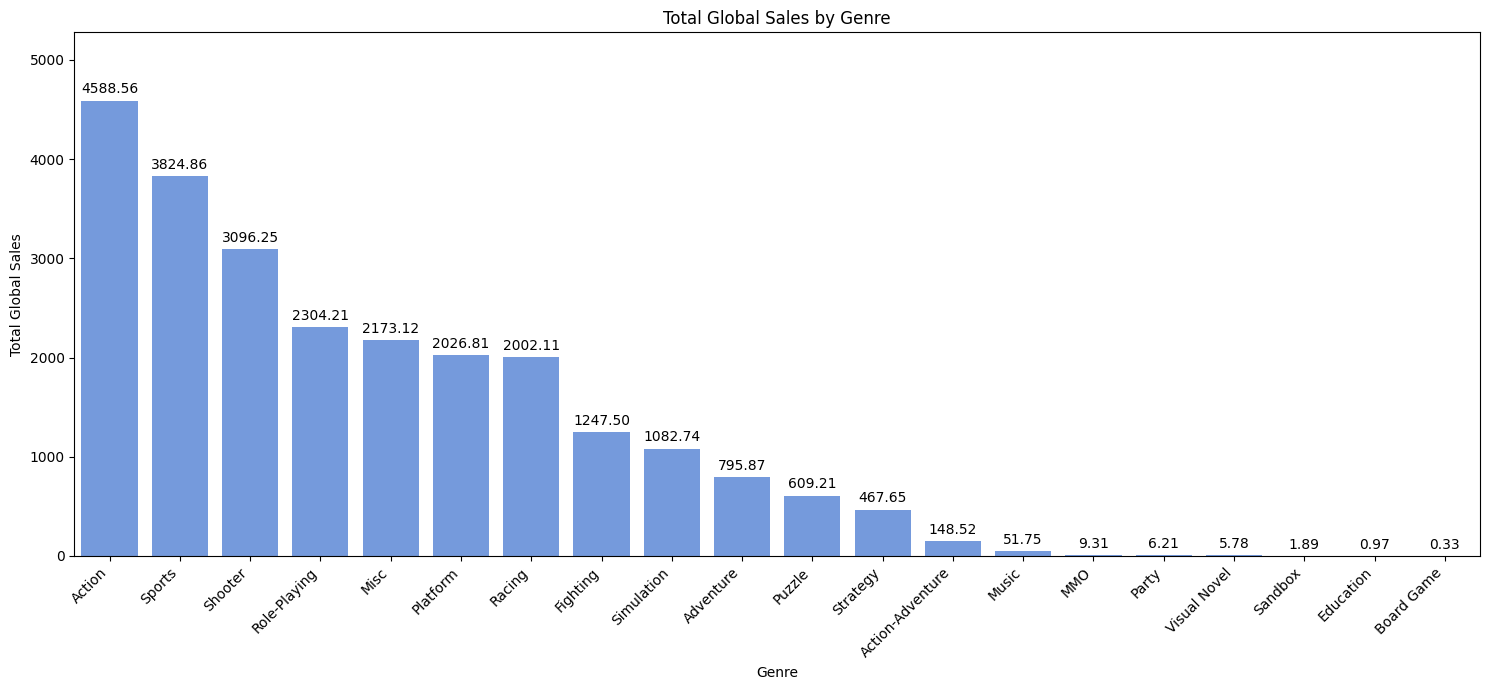

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_sales = final_df.groupby('genre')['global_sales'].sum().reset_index()
genre_sales = genre_sales.sort_values(by='global_sales', ascending=False)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=genre_sales,
    x='genre',
    y='global_sales',
    color='cornflowerblue'
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.ylim(0, genre_sales['global_sales'].max() * 1.15)

plt.xticks(rotation=45, ha='right')
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales")

plt.tight_layout()
plt.show()

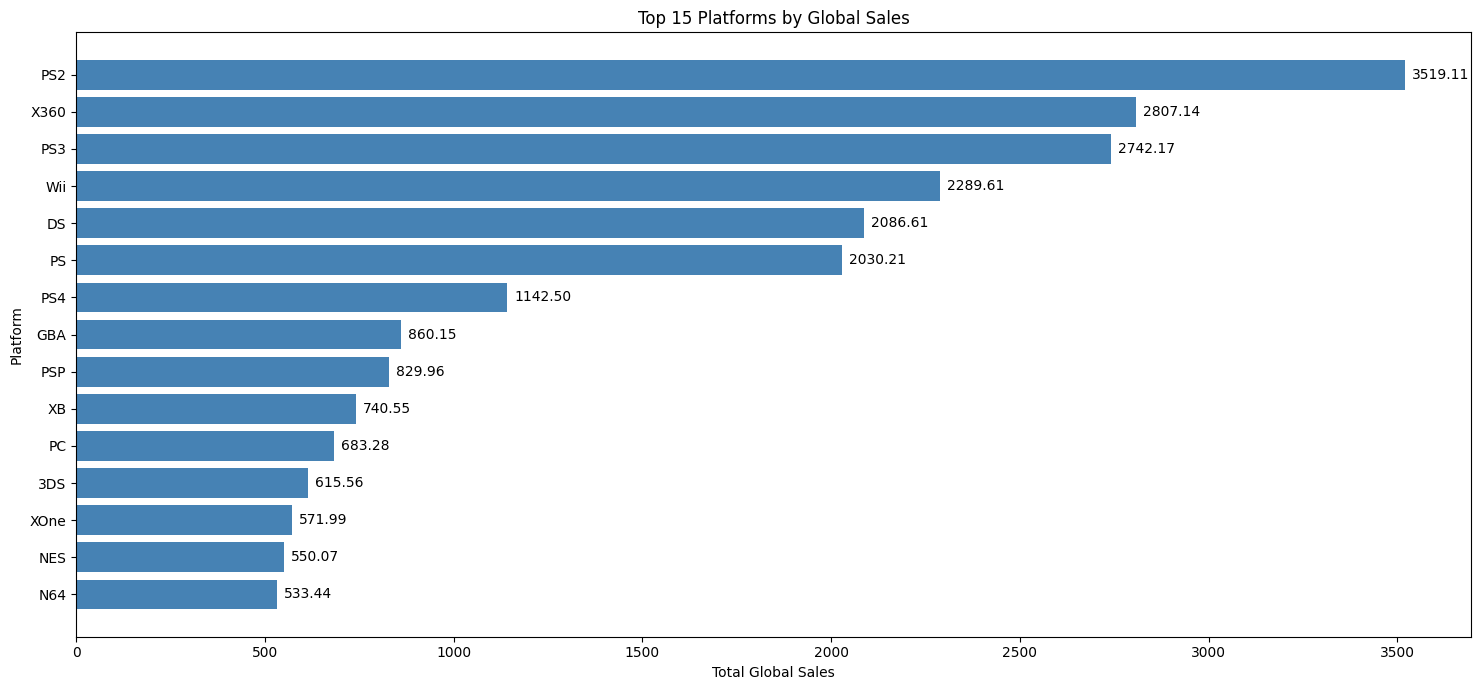

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# global_sales sayısal olsun
final_df['global_sales'] = pd.to_numeric(final_df['global_sales'], errors='coerce')

# Platformlara göre toplam satış
platform_sales = (
    final_df
    .dropna(subset=['platform', 'global_sales'])
    .groupby('platform', as_index=False)['global_sales']
    .sum()
    .sort_values(by='global_sales', ascending=False)
)

# İlk 15 platformu alalım
top_platform_sales = platform_sales.head(15)

plt.figure(figsize=(15, 7))

bars = plt.barh(
    top_platform_sales['platform'],
    top_platform_sales['global_sales'],
    color='steelblue'
)

# En yüksek değer üstte görünsün
plt.gca().invert_yaxis()

# Çubukların sonuna değer yazdırma
plt.bar_label(bars, fmt='%.2f', padding=5)

plt.title("Top 15 Platforms by Global Sales")
plt.xlabel("Total Global Sales")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()

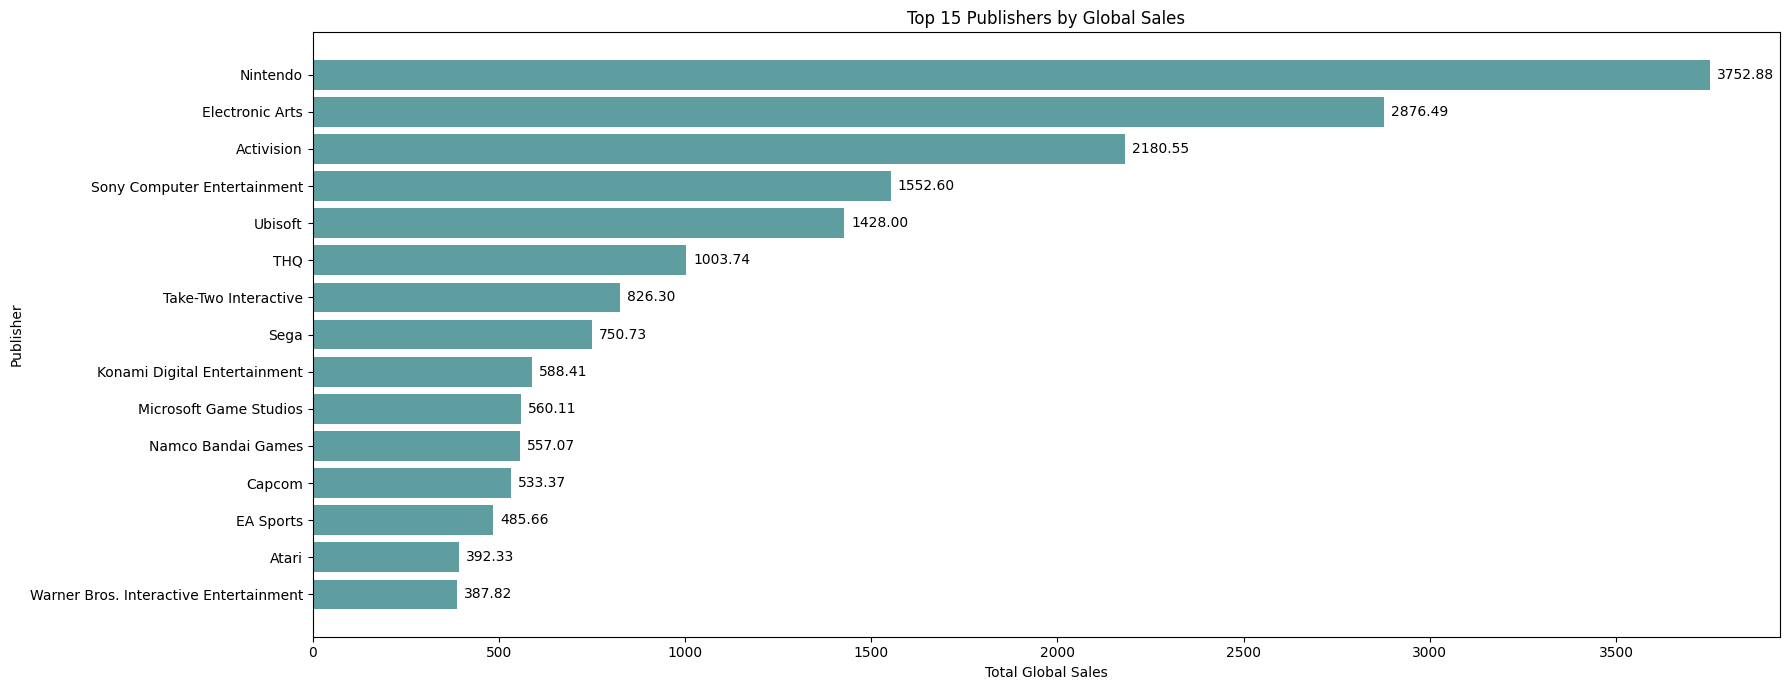

In [15]:
import matplotlib.pyplot as plt

publisher_sales = final_df.groupby('publisher')['global_sales'].sum().reset_index()
publisher_sales = publisher_sales.sort_values(by='global_sales', ascending=False).head(15)

plt.figure(figsize=(18, 7))

bars = plt.barh(
    publisher_sales['publisher'],
    publisher_sales['global_sales'],
    color='cadetblue'
)

plt.gca().invert_yaxis()

plt.bar_label(bars, fmt='%.2f', padding=5)

plt.title("Top 15 Publishers by Global Sales")
plt.xlabel("Total Global Sales")
plt.ylabel("Publisher")

plt.tight_layout()
plt.show()

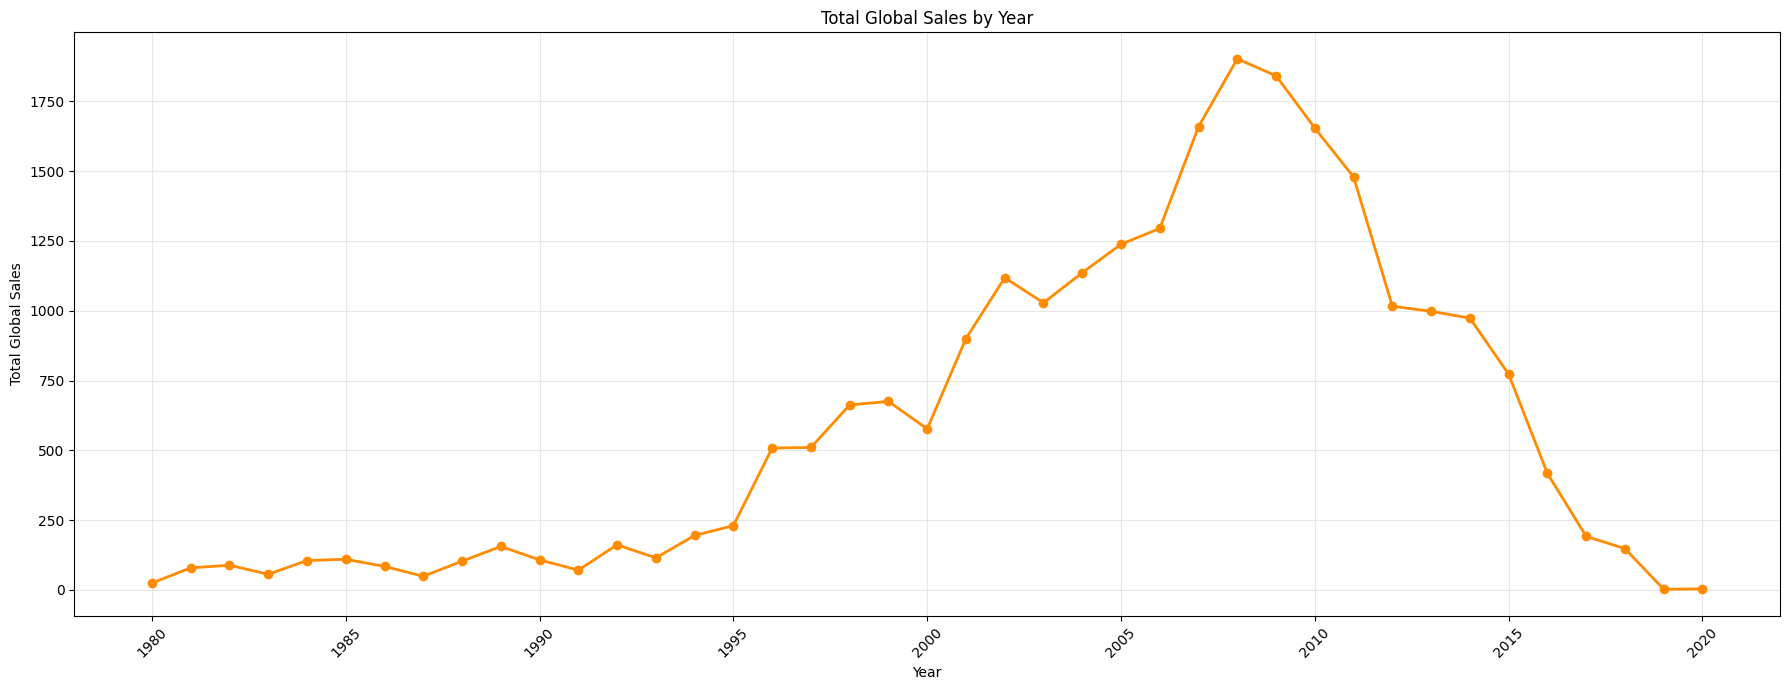

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

final_df['year'] = pd.to_numeric(final_df['year'], errors='coerce')

year_sales = final_df.groupby('year')['global_sales'].sum().reset_index()
year_sales = year_sales.dropna()
year_sales = year_sales.sort_values(by='year')

plt.figure(figsize=(18, 7))

plt.plot(
    year_sales['year'],
    year_sales['global_sales'],
    marker='o',
    linewidth=2,
    color='darkorange'
)

plt.title("Total Global Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Global Sales")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

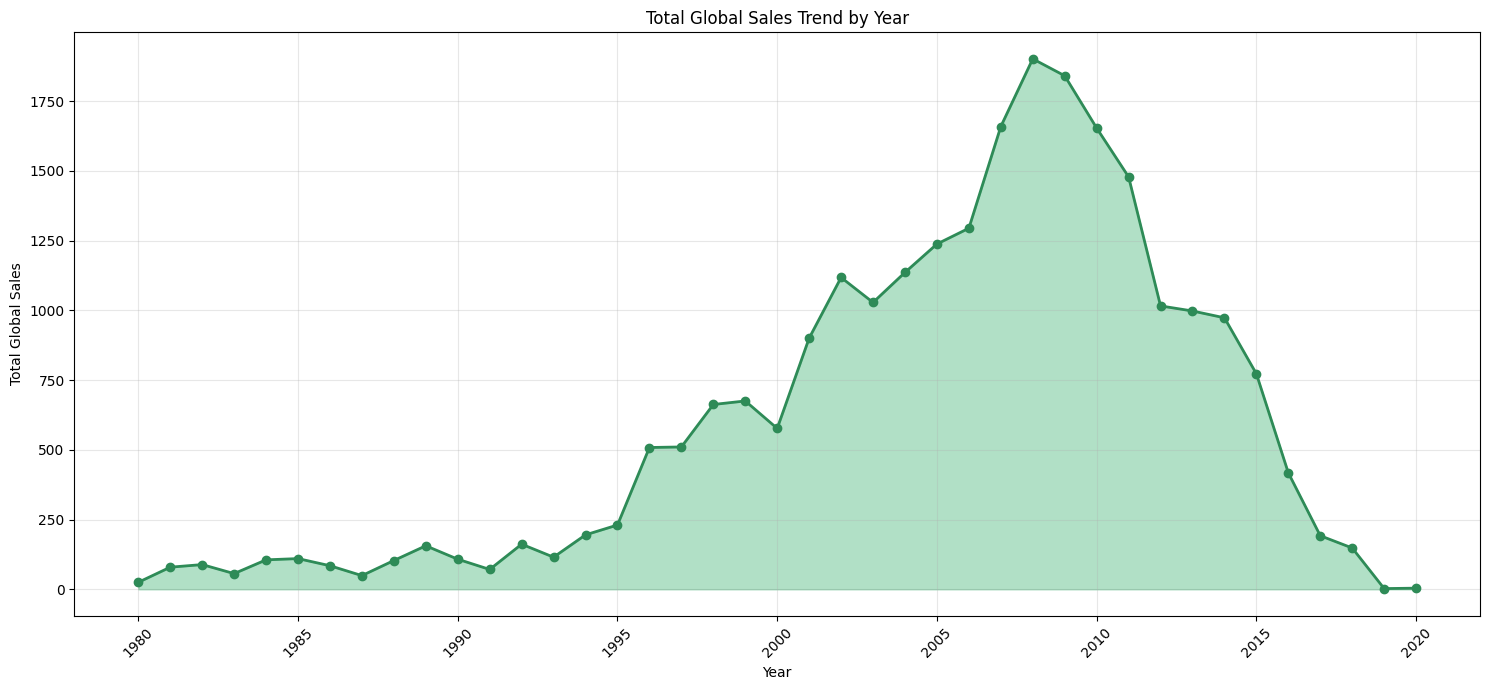

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

final_df['year'] = pd.to_numeric(final_df['year'], errors='coerce')

year_sales = final_df.groupby('year')['global_sales'].sum().reset_index()
year_sales = year_sales.dropna()
year_sales = year_sales.sort_values(by='year')

plt.figure(figsize=(15, 7))

plt.fill_between(
    year_sales['year'],
    year_sales['global_sales'],
    alpha=0.4,
    color='mediumseagreen'
)

plt.plot(
    year_sales['year'],
    year_sales['global_sales'],
    marker='o',
    linewidth=2,
    color='seagreen'
)

plt.title("Total Global Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Global Sales")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

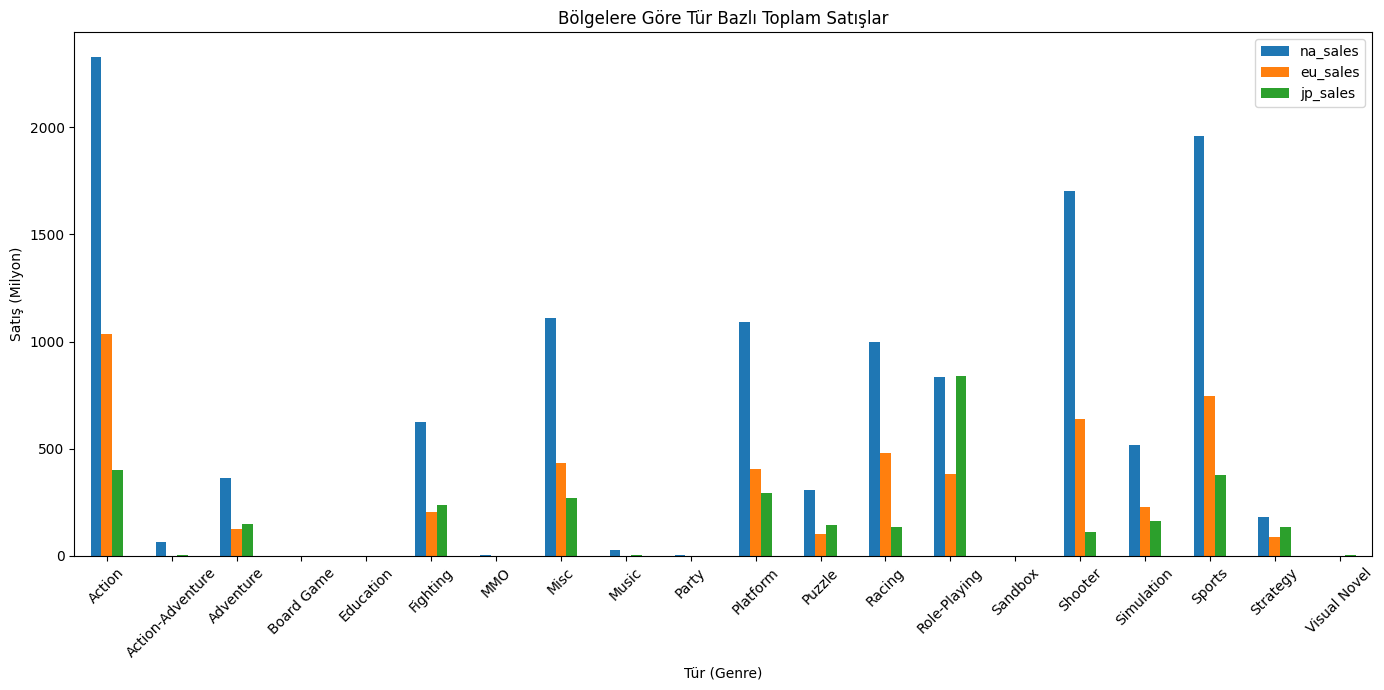

In [18]:
import matplotlib.pyplot as plt

# Genre bazlı toplam satışlar
genre_sales = final_df.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Grafik
genre_sales.plot(kind='bar', figsize=(14,7))
plt.title("Bölgelere Göre Tür Bazlı Toplam Satışlar")
plt.xlabel("Tür (Genre)")
plt.ylabel("Satış (Milyon)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

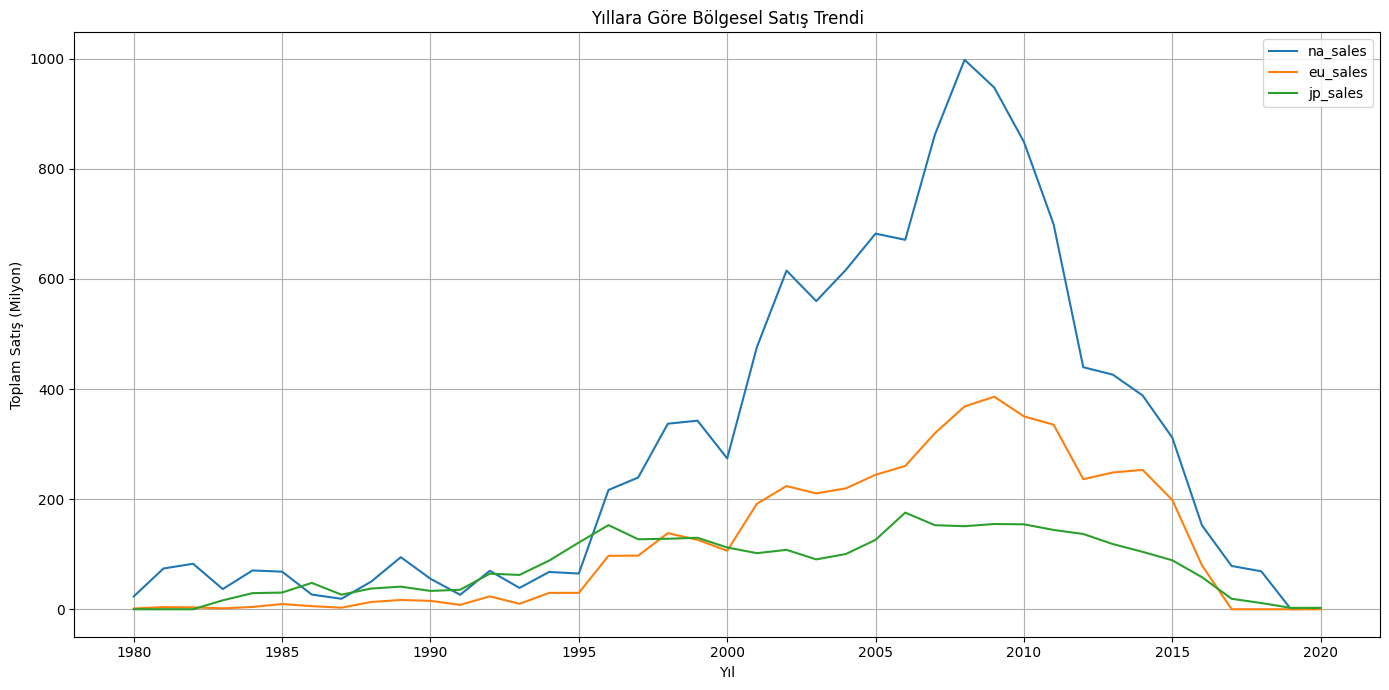

In [19]:
# Yıl bazlı toplam satış
yearly_sales = final_df.groupby('year')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Grafik
yearly_sales.plot(figsize=(14,7))
plt.title("Yıllara Göre Bölgesel Satış Trendi")
plt.xlabel("Yıl")
plt.ylabel("Toplam Satış (Milyon)")
plt.grid(True)
plt.tight_layout()
plt.show()

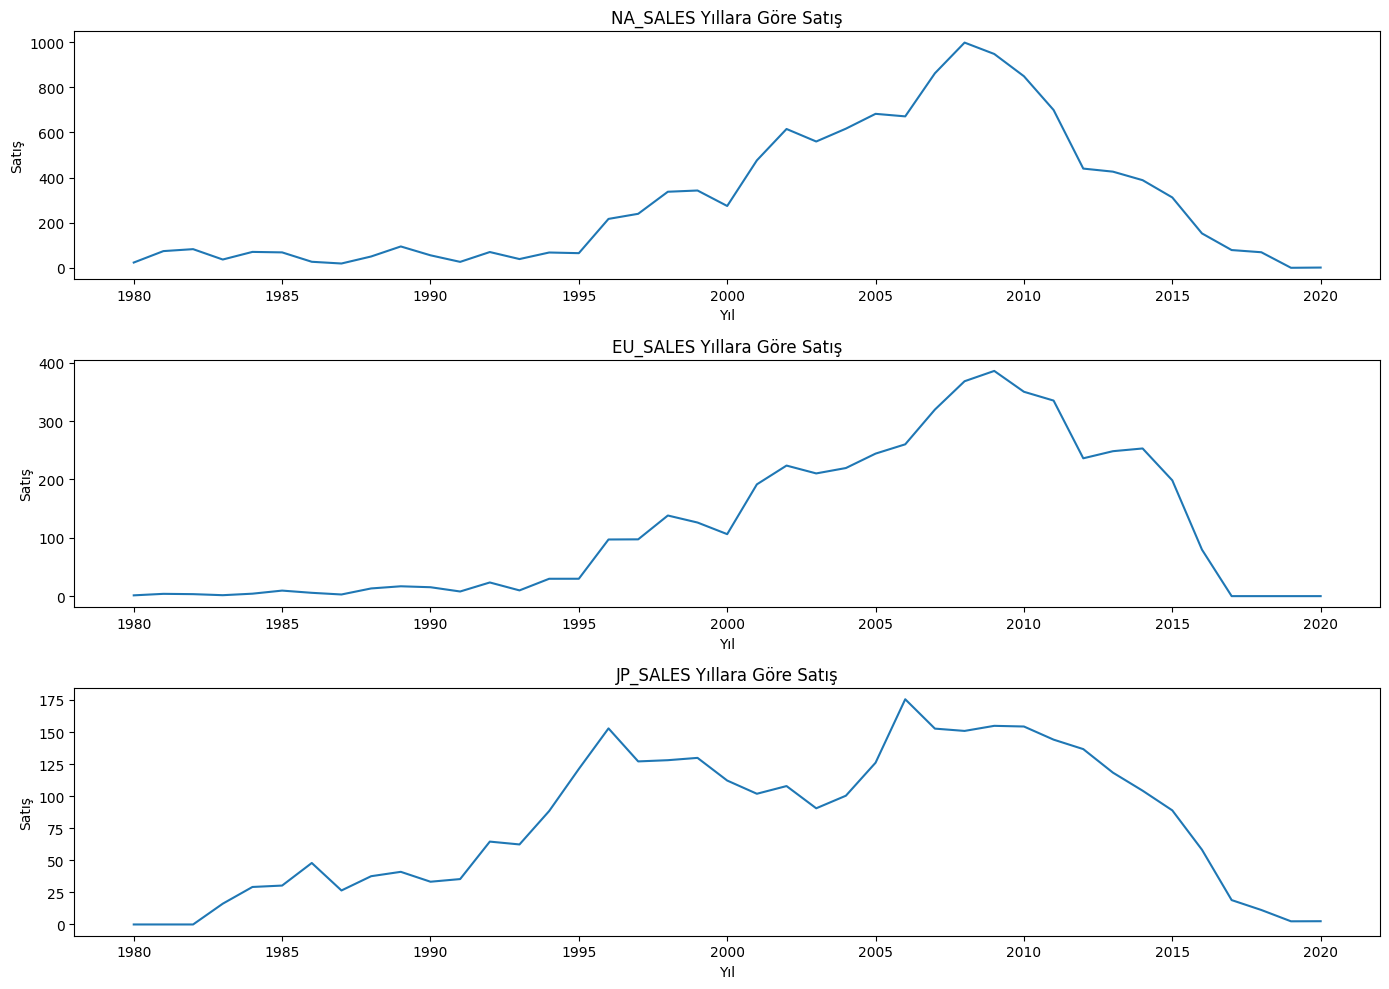

In [20]:
regions = ['na_sales', 'eu_sales', 'jp_sales']

plt.figure(figsize=(14,10))

for i, region in enumerate(regions, 1):
    plt.subplot(3,1,i)
    final_df.groupby('year')[region].sum().plot()
    plt.title(f"{region.upper()} Yıllara Göre Satış")
    plt.xlabel("Yıl")
    plt.ylabel("Satış")

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Bölgesel satış sütunları
region_cols = ['na_sales', 'eu_sales', 'jp_sales']

# Sayısala çevir
for col in region_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

# Gerekli sütunlarda boş olanları temizle
temp_df = final_df[['platform', 'genre'] + region_cols].copy()
temp_df[region_cols] = temp_df[region_cols].fillna(0)

# Uzun formata çevir
long_df = temp_df.melt(
    id_vars=['platform', 'genre'],
    value_vars=region_cols,
    var_name='region',
    value_name='sales'
)

# Bölge isimlerini daha güzel yap
long_df['region'] = long_df['region'].replace({
    'na_sales': 'North America',
    'eu_sales': 'Europe',
    'jp_sales': 'Japan'
})

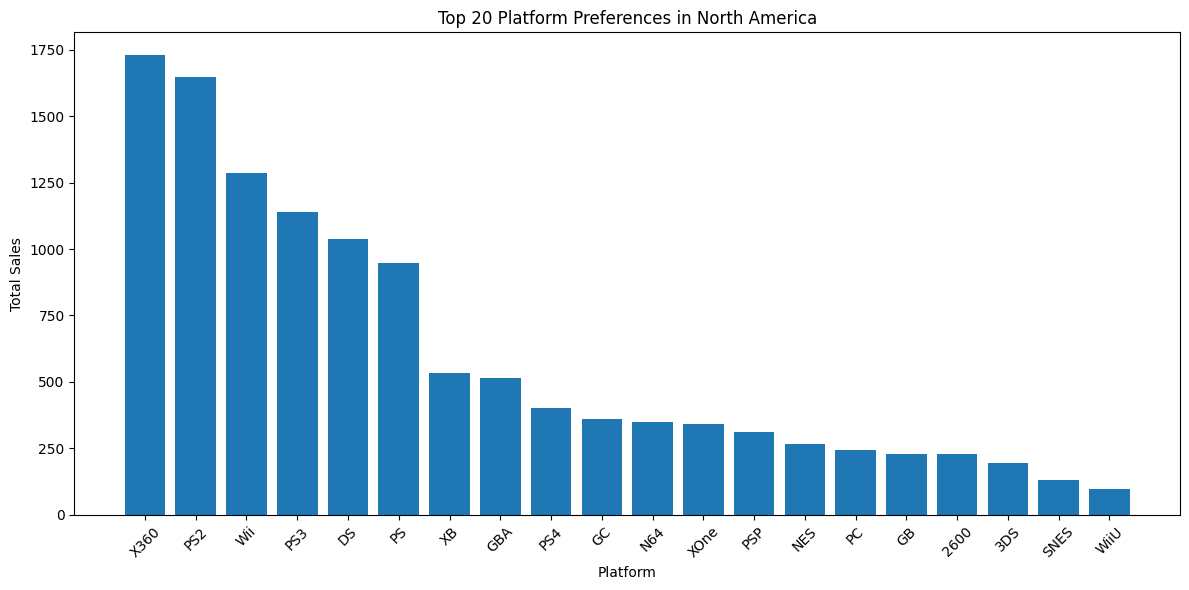

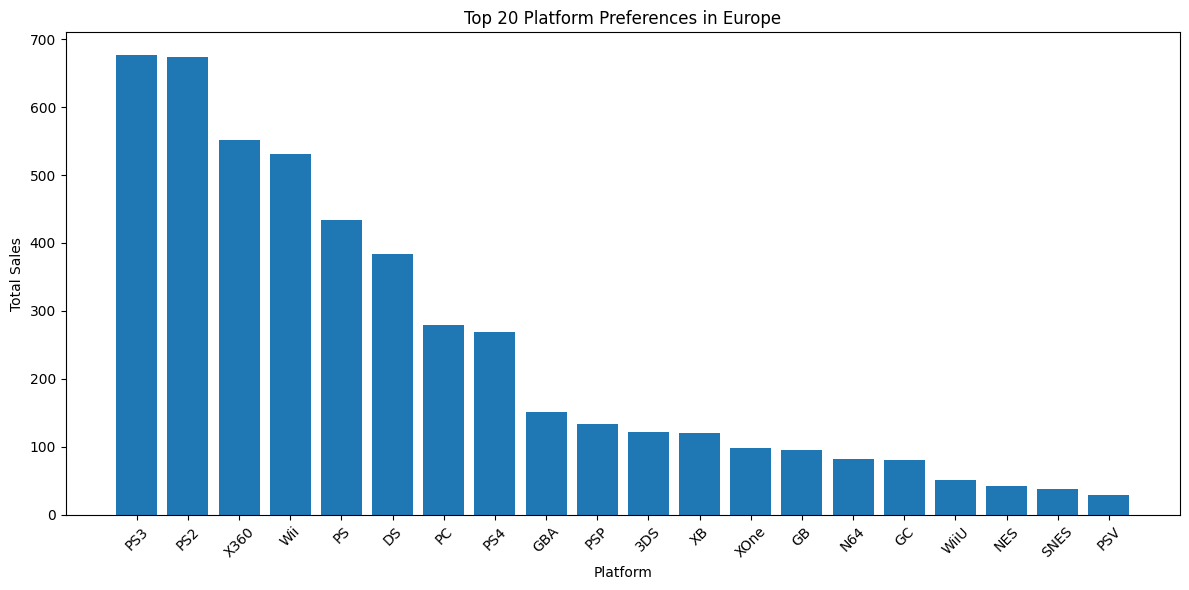

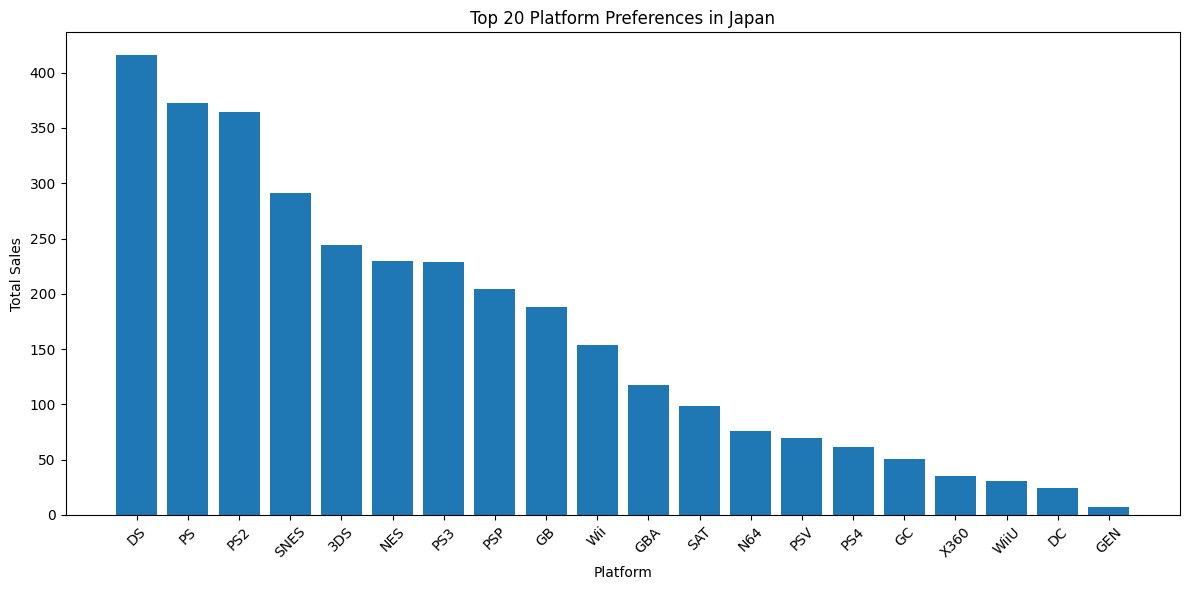

In [22]:
platform_pref = (
    long_df
    .groupby(['region', 'platform'])['sales']
    .sum()
    .reset_index()
)

regions = ['North America', 'Europe', 'Japan']

for region in regions:
    top_platforms = (
        platform_pref[platform_pref['region'] == region]
        .sort_values(by='sales', ascending=False)
        .head(20)
    )

    plt.figure(figsize=(12, 6))
    plt.bar(top_platforms['platform'], top_platforms['sales'])
    plt.title(f'Top 20 Platform Preferences in {region}')
    plt.xlabel('Platform')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

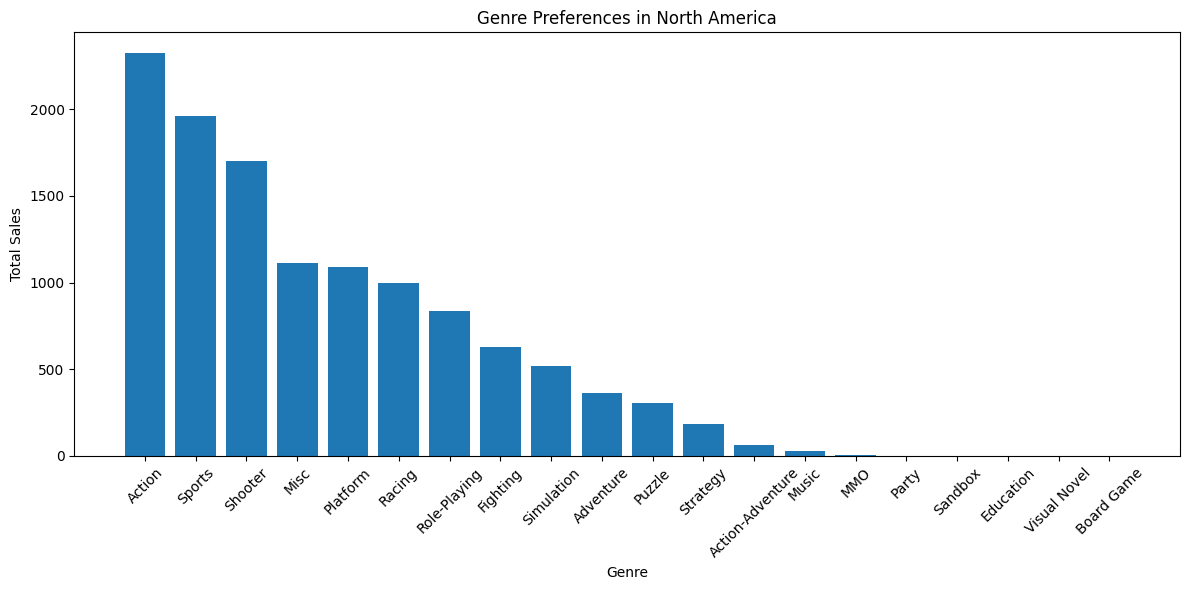

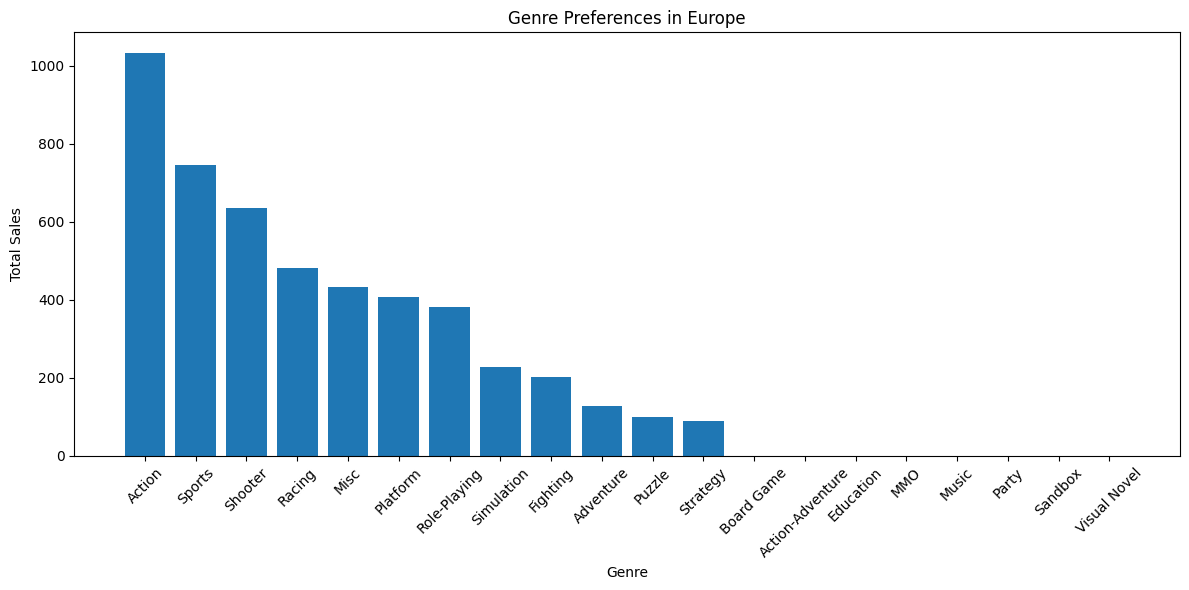

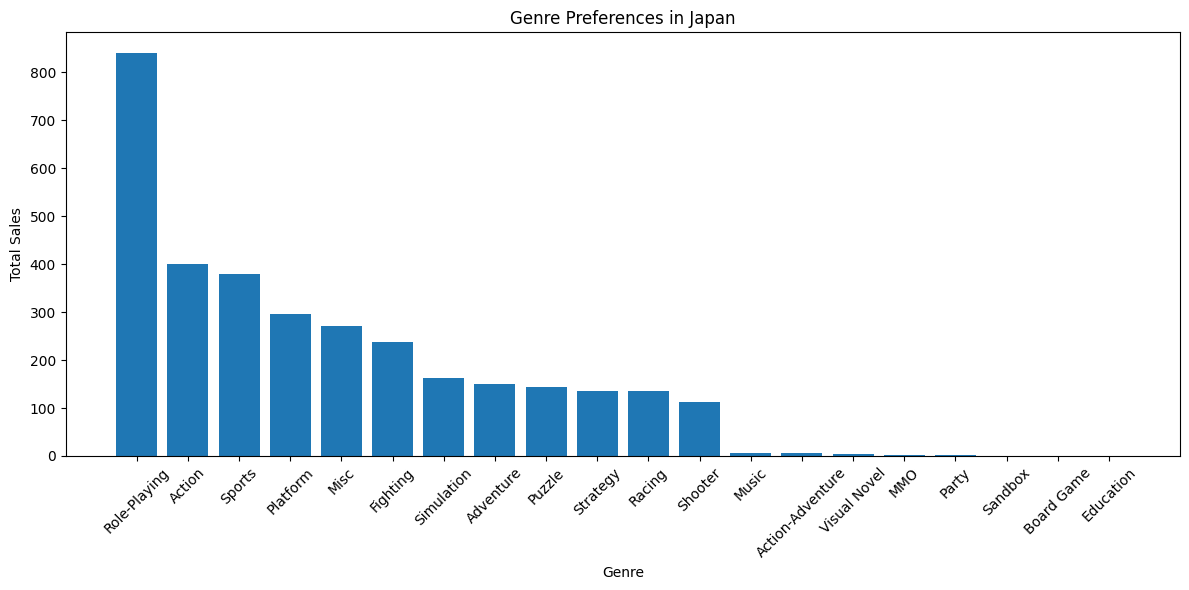

In [23]:
genre_pref = (
    long_df
    .groupby(['region', 'genre'])['sales']
    .sum()
    .reset_index()
)

for region in regions:
    top_genres = (
        genre_pref[genre_pref['region'] == region]
        .sort_values(by='sales', ascending=False)
    )

    plt.figure(figsize=(12, 6))
    plt.bar(top_genres['genre'], top_genres['sales'])
    plt.title(f'Genre Preferences in {region}')
    plt.xlabel('Genre')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
import matplotlib.pyplot as plt

cute_colors = ['#FF8FAB', '#7BDFF2', '#B2F7A5']
# pembe, açık mavi, yeşil

region_order = ['North America', 'Europe', 'Japan']

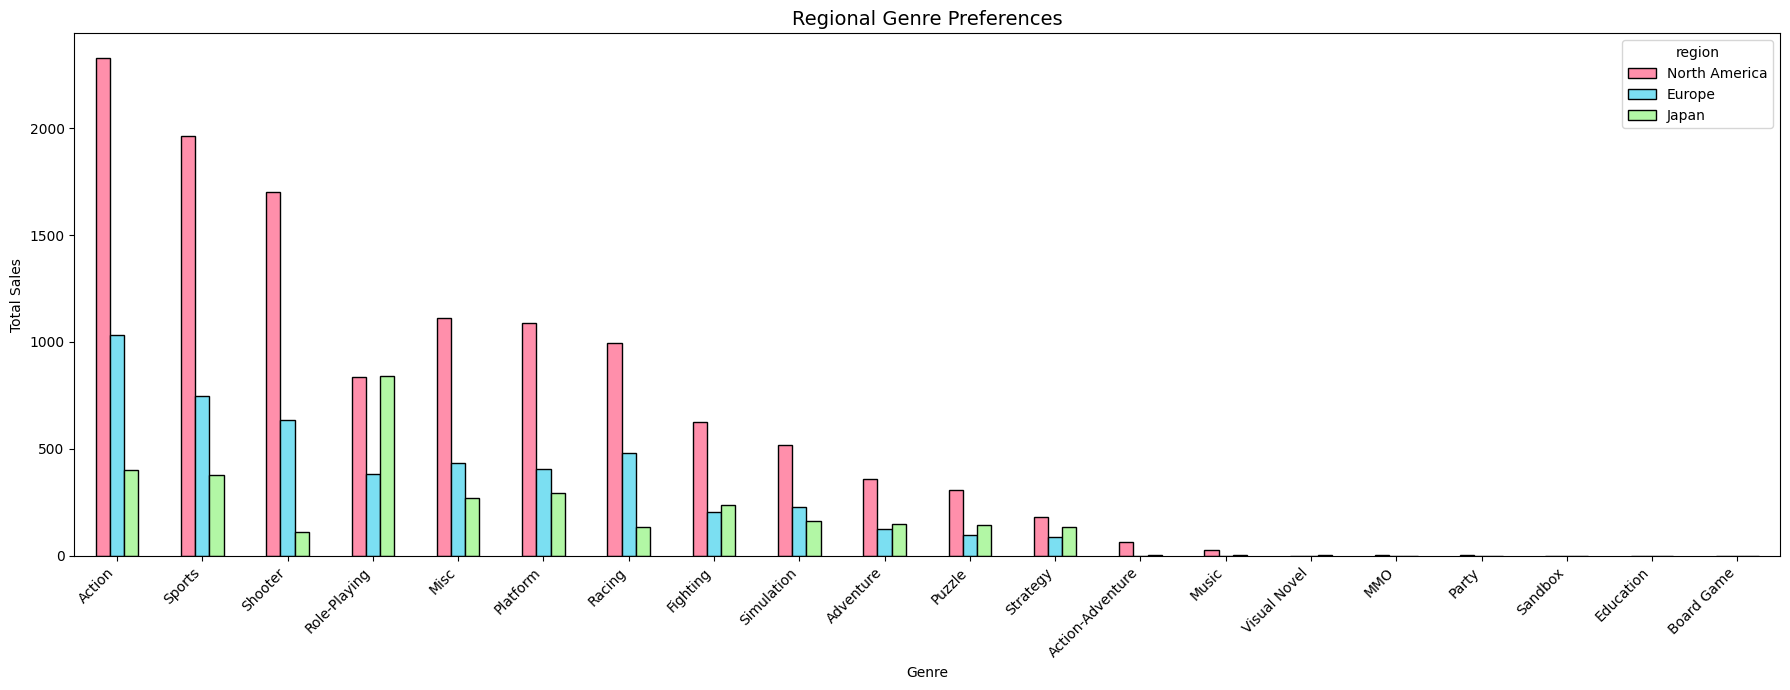

In [25]:
genre_pivot = (
    long_df
    .groupby(['genre', 'region'])['sales']
    .sum()
    .unstack()
    .fillna(0)
)

# Bölge sütunlarını düzgün sırala
genre_pivot = genre_pivot.reindex(columns=region_order)

# Toplam satışa göre azalan sırala
genre_pivot['total_sales'] = genre_pivot.sum(axis=1)
genre_pivot = genre_pivot.sort_values(by='total_sales', ascending=False)
genre_pivot = genre_pivot.drop(columns='total_sales')

# Grafik
genre_pivot.plot(
    kind='bar',
    figsize=(18, 7),
    color=cute_colors,
    edgecolor='black'
)

plt.title('Regional Genre Preferences', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

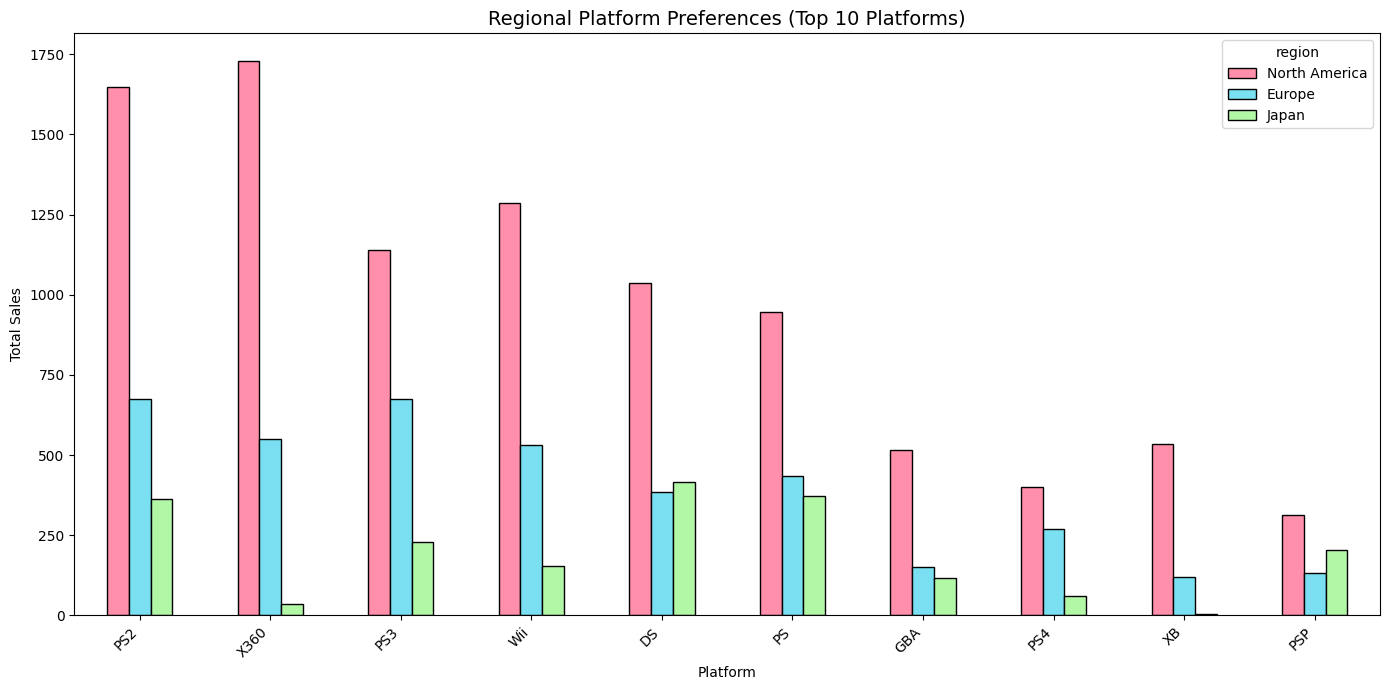

In [26]:
platform_total = (
    long_df
    .groupby('platform')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

platform_pivot = (
    long_df[long_df['platform'].isin(platform_total)]
    .groupby(['platform', 'region'])['sales']
    .sum()
    .unstack()
    .fillna(0)
)

# Bölge sütunlarını düzgün sırala
platform_pivot = platform_pivot.reindex(columns=region_order)

# Toplam satışa göre azalan sırala
platform_pivot['total_sales'] = platform_pivot.sum(axis=1)
platform_pivot = platform_pivot.sort_values(by='total_sales', ascending=False)
platform_pivot = platform_pivot.drop(columns='total_sales')

# Grafik
platform_pivot.plot(
    kind='bar',
    figsize=(14, 7),
    color=cute_colors,
    edgecolor='black'
)

plt.title('Regional Platform Preferences (Top 10 Platforms)', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
model_df = final_df.copy()

In [28]:
import pandas as pd
import numpy as np

sales_cols = ['global_sales', 'na_sales', 'eu_sales', 'jp_sales']

for col in sales_cols:
   model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

In [29]:
model_df['global_sales'].describe()

,global_sales
count,51803.000000
mean,0.471905
std,1.342563
min,0.000000
25%,0.050000
50%,0.150000
75%,0.430000
max,82.740000


In [30]:
# model_df['global_sales'].quantile([0.33, 0.66])

In [31]:
# q1 = model_df['global_sales'].quantile(0.33)
# q2 = model_df['global_sales'].quantile(0.66)

# def sales_class(x):
    #  if x <= q1:
        #  return 'low'
    #  elif x <= q2:
        #  return 'medium'
    #  else:
        #  return 'high'

# model_df['sales_class'] = model_df['global_sales'].apply(sales_class)

In [32]:
model_df['sales_class'] = pd.qcut(
    model_df['global_sales'],
    q=3,
    labels=['low', 'medium', 'high']
)

In [33]:
model_df[['name', 'global_sales', 'sales_class']].head(10)

,name,global_sales,sales_class
0,Wii Sports,82.74,high
1,Super Mario Bros.,40.24,high
2,Mario Kart Wii,35.82,high
3,Wii Sports Resort,33.00,high
4,Pokemon Red/Pokemon Blue,31.37,high
5,Tetris,30.26,high
6,New Super Mario Bros.,30.01,high
7,Wii Play,29.02,high
8,New Super Mario Bros. Wii,28.62,high
9,Duck Hunt,28.31,high


In [34]:
model_df['sales_class'].value_counts()

,count
sales_class,
low,18612
high,17232
medium,15959


In [35]:
model_df['sales_class'].value_counts(normalize=True) * 100

,proportion
sales_class,
low,35.928421
high,33.264483
medium,30.807096


In [36]:
import pandas as pd
import numpy as np

model_df['year'] = pd.to_numeric(model_df['year'], errors='coerce')
model_df['critic_score'] = pd.to_numeric(model_df['critic_score'], errors='coerce')
model_df['user_score'] = pd.to_numeric(model_df['user_score'], errors='coerce')
model_df['global_sales'] = pd.to_numeric(model_df['global_sales'], errors='coerce')

In [37]:
top_publishers = model_df['publisher'].value_counts().head(15).index

model_df['publisher_grouped'] = model_df['publisher'].apply(
    lambda x: x if x in top_publishers else 'Other'
)

*Modelde kullanacağımız özellikler*

In [38]:
features = [
    'platform',
    'year',
    'genre',
    'publisher_grouped'
]

X = model_df[features]
y = model_df['sales_class']

In [39]:
model_df['critic_score'].isna().mean() * 100
# user ve critic score çıkartıldı ilk modelden

np.float64(76.39905024805513)

In [40]:
X = X.copy()

X['platform'] = X['platform'].fillna('Unknown')
X['genre'] = X['genre'].fillna('Unknown')
X['publisher_grouped'] = X['publisher_grouped'].fillna('Unknown')

X['year'] = X['year'].fillna(X['year'].median())

*one-hot encoding*

In [41]:
X_encoded = pd.get_dummies(
    X,
    columns=['platform', 'genre', 'publisher_grouped'],
    drop_first=True
)

In [42]:
X_encoded.head()

,year,platform_3DO,platform_3DS,platform_DC,platform_DS,platform_GB,platform_GBA,platform_GBC,platform_GC,platform_GEN,...,publisher_grouped_Namco Bandai Games,publisher_grouped_Nintendo,publisher_grouped_Other,publisher_grouped_Sega,publisher_grouped_Sony Computer Entertainment,publisher_grouped_Square Enix,publisher_grouped_THQ,publisher_grouped_Take-Two Interactive,publisher_grouped_Tecmo Koei,publisher_grouped_Ubisoft
0,2006,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,1985,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,2008,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,2009,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,1996,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [43]:
X_encoded.shape

(51803, 75)

In [44]:
X_encoded.isna().sum().sum()

np.int64(0)

*train-test split + baseline model aşaması*

In [45]:
y = model_df['sales_class']

In [46]:
y.value_counts()

,count
sales_class,
low,18612
high,17232
medium,15959


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
test_size=0.2

In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

dummy_model = DummyClassifier(strategy='most_frequent')

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print("Dummy Model Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))

Dummy Model Accuracy: 0.35932825016890263
              precision    recall  f1-score   support

        high       0.00      0.00      0.00      3446
         low       0.36      1.00      0.53      3723
      medium       0.00      0.00      0.00      3192

    accuracy                           0.36     10361
   macro avg       0.12      0.33      0.18     10361
weighted avg       0.13      0.36      0.19     10361



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=12
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.5533249686323714
              precision    recall  f1-score   support

        high       0.56      0.57      0.57      3446
         low       0.66      0.64      0.65      3723
      medium       0.42      0.43      0.43      3192

    accuracy                           0.55     10361
   macro avg       0.55      0.55      0.55     10361
weighted avg       0.55      0.55      0.55     10361



In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100, # Increased n_estimators for better performance
    random_state=42, # Added random_state for reproducibility
    max_depth=12,
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5845960814593186
              precision    recall  f1-score   support

        high       0.56      0.72      0.63      3446
         low       0.63      0.72      0.67      3723
      medium       0.54      0.28      0.37      3192

    accuracy                           0.58     10361
   macro avg       0.58      0.57      0.56     10361
weighted avg       0.58      0.58      0.56     10361



In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Denenecek parametreler
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Ana model
rf_model = RandomForestClassifier(
    random_state=42
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Eğitim
grid_search.fit(X_train, y_train)

# En iyi modeli al
best_rf_model = grid_search.best_estimator_

# Test verisiyle tahmin yap
y_pred_rf = best_rf_model.predict(X_test)

# Sonuçları yazdır
print("En iyi parametreler:")
print(grid_search.best_params_)

print("En iyi Cross Validation skoru:")
print(grid_search.best_score_)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

En iyi parametreler:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
En iyi Cross Validation skoru:
0.6236148264124708
Random Forest Test Accuracy: 0.6431811601196795
              precision    recall  f1-score   support

        high       0.66      0.67      0.67      3446
         low       0.69      0.73      0.71      3723
      medium       0.56      0.52      0.54      3192

    accuracy                           0.64     10361
   macro avg       0.64      0.64      0.64     10361
weighted avg       0.64      0.64      0.64     10361



In [53]:
print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Dummy Accuracy: 0.35932825016890263
Decision Tree Accuracy: 0.5533249686323714
Random Forest Accuracy: 0.6431811601196795


In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

# Eğitim
random_search.fit(X_train, y_train)

# En iyi model
best_rf_model = random_search.best_estimator_

# Test tahmini
y_pred_rf = best_rf_model.predict(X_test)

# Çıktılar
print("En iyi parametreler:")
print(random_search.best_params_)

print("\nEn iyi Cross Validation skoru:")
print(random_search.best_score_)

print("\nRandom Forest Test Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

En iyi parametreler:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

En iyi Cross Validation skoru:
0.6236148264124708

Random Forest Test Accuracy:
0.6431811601196795

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.67      0.67      3446
         low       0.69      0.73      0.71      3723
      medium       0.56      0.52      0.54      3192

    accuracy                           0.64     10361
   macro avg       0.64      0.64      0.64     10361
weighted avg       0.64      0.64      0.64     10361



In [55]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Parametre aralığı
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Model
rf_model = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=15,              # biraz artırdık (daha iyi sonuç için)
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

# Eğitim
random_search.fit(X_train, y_train)

# En iyi model
best_rf_model = random_search.best_estimator_

# Test tahmini
y_pred_rf = best_rf_model.predict(X_test)

# Çıktılar (SENİN FORMATINDA)
print("En iyi parametreler:")
print(random_search.best_params_)

print("\nEn iyi Cross Validation skoru:")
print(random_search.best_score_)

print("\nRandom Forest Test Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

En iyi parametreler:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

En iyi Cross Validation skoru:
0.6236148264124708

Random Forest Test Accuracy:
0.6431811601196795

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.67      0.67      3446
         low       0.69      0.73      0.71      3723
      medium       0.56      0.52      0.54      3192

    accuracy                           0.64     10361
   macro avg       0.64      0.64      0.64     10361
weighted avg       0.64      0.64      0.64     10361



In [56]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
    )

# Eğitim
gb_model.fit(X_train, y_train)

# Tahmin
y_pred_gb = gb_model.predict(X_test)

# Çıktılar (RF ile aynı format)
print("Gradient Boosting Test Accuracy:")
print(accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Test Accuracy:
0.5683814303638645

Classification Report:
              precision    recall  f1-score   support

        high       0.57      0.67      0.61      3446
         low       0.64      0.66      0.65      3723
      medium       0.46      0.34      0.39      3192

    accuracy                           0.57     10361
   macro avg       0.55      0.56      0.55     10361
weighted avg       0.56      0.57      0.56     10361



In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr_model = LogisticRegression(max_iter=1000)

# Eğitim
lr_model.fit(X_train_scaled, y_train)

# Tahmin
y_pred_lr = lr_model.predict(X_test_scaled)

# Çıktı (RF formatında)
print("Logistic Regression Test Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test Accuracy:
0.5384615384615384

Classification Report:
              precision    recall  f1-score   support

        high       0.55      0.62      0.58      3446
         low       0.58      0.71      0.64      3723
      medium       0.41      0.25      0.32      3192

    accuracy                           0.54     10361
   macro avg       0.52      0.53      0.51     10361
weighted avg       0.52      0.54      0.52     10361



In [58]:
threshold_df = model_df.copy()

In [59]:
threshold_df['global_sales'] = pd.to_numeric(threshold_df['global_sales'], errors='coerce')
threshold_df = threshold_df.dropna(subset=['global_sales'])

sales_threshold = threshold_df['global_sales'].quantile(0.75)

threshold_df['investment_class'] = threshold_df['global_sales'].apply(
    lambda x: 'good_investment' if x >= sales_threshold else 'risky_investment'
)

threshold_df['investment_class'].value_counts()

,count
investment_class,
risky_investment,38680
good_investment,13123


In [60]:
features = [
    'platform',
    'year',
    'genre',
    'publisher_grouped'
]

X_binary = threshold_df[features]
y_binary = threshold_df['investment_class']

In [61]:
X_binary = X_binary.copy()

X_binary['platform'] = X_binary['platform'].fillna('Unknown')
X_binary['genre'] = X_binary['genre'].fillna('Unknown')
X_binary['publisher_grouped'] = X_binary['publisher_grouped'].fillna('Unknown')
X_binary['year'] = X_binary['year'].fillna(X_binary['year'].median())

In [62]:
X_binary_encoded = pd.get_dummies(
    X_binary,
    columns=['platform', 'genre', 'publisher_grouped'],
    drop_first=True
)

In [63]:
from sklearn.model_selection import train_test_split

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary_encoded,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_binary = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=12,
    class_weight = 'balanced'
)

rf_binary.fit(X_train_bin, y_train_bin)

y_pred_bin = rf_binary.predict(X_test_bin)

print("Binary Model Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print(classification_report(y_test_bin, y_pred_bin))

Binary Model Accuracy: 0.7082327960621562
                  precision    recall  f1-score   support

 good_investment       0.45      0.72      0.55      2625
risky_investment       0.88      0.71      0.78      7736

        accuracy                           0.71     10361
       macro avg       0.67      0.71      0.67     10361
    weighted avg       0.77      0.71      0.73     10361



In [65]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

dummy_bin = DummyClassifier(strategy='most_frequent')

dummy_bin.fit(X_train_bin, y_train_bin)
y_pred_dummy_bin = dummy_bin.predict(X_test_bin)

print("Dummy Accuracy:", accuracy_score(y_test_bin, y_pred_dummy_bin))
print(classification_report(y_test_bin, y_pred_dummy_bin))

Dummy Accuracy: 0.7466460766335296
                  precision    recall  f1-score   support

 good_investment       0.00      0.00      0.00      2625
risky_investment       0.75      1.00      0.85      7736

        accuracy                           0.75     10361
       macro avg       0.37      0.50      0.43     10361
    weighted avg       0.56      0.75      0.64     10361



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score

rf_binary_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=12,
    class_weight='balanced'
)

rf_binary_balanced.fit(X_train_bin, y_train_bin)

y_pred_balanced = rf_binary_balanced.predict(X_test_bin)

print("Accuracy:", accuracy_score(y_test_bin, y_pred_balanced))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_bin, y_pred_balanced))
print("F1 Macro:", f1_score(y_test_bin, y_pred_balanced, average='macro'))
print(classification_report(y_test_bin, y_pred_balanced, zero_division=0))

Accuracy: 0.7072676382588553
Balanced Accuracy: 0.7122286896144188
F1 Macro: 0.6686779263767102
                  precision    recall  f1-score   support

 good_investment       0.45      0.72      0.56      2625
risky_investment       0.88      0.70      0.78      7736

        accuracy                           0.71     10361
       macro avg       0.67      0.71      0.67     10361
    weighted avg       0.77      0.71      0.72     10361



In [67]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score

good_index = list(rf_binary_balanced.classes_).index('good_investment')
good_probs = rf_binary_balanced.predict_proba(X_test_bin)[:, good_index]

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_threshold = np.where(
        good_probs >= threshold,
        'good_investment',
        'risky_investment'
    )

    print("Threshold:", threshold)
    print("Accuracy:", accuracy_score(y_test_bin, y_pred_threshold))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test_bin, y_pred_threshold))
    print("F1 Macro:", f1_score(y_test_bin, y_pred_threshold, average='macro'))
    print("Good Precision:", precision_score(y_test_bin, y_pred_threshold, pos_label='good_investment'))
    print("Good Recall:", recall_score(y_test_bin, y_pred_threshold, pos_label='good_investment'))
    print("-" * 40)

Threshold: 0.3
Accuracy: 0.4408840845478236
Balanced Accuracy: 0.6150108583247156
F1 Macro: 0.43950466972261815
Good Precision: 0.308
Good Recall: 0.968
----------------------------------------
Threshold: 0.35
Accuracy: 0.4869221117652736
Balanced Accuracy: 0.642820505244497
F1 Macro: 0.4869215334484705
Good Precision: 0.3258252427184466
Good Recall: 0.9588571428571429
----------------------------------------
Threshold: 0.4
Accuracy: 0.5797702924428144
Balanced Accuracy: 0.6872534347761856
F1 Macro: 0.5735129495643292
Good Precision: 0.36661009103533404
Good Recall: 0.9051428571428571
----------------------------------------
Threshold: 0.45
Accuracy: 0.6554386642216002
Balanced Accuracy: 0.7146446053085143
F1 Macro: 0.6357474329138495
Good Precision: 0.41130091984231276
Good Recall: 0.8346666666666667
----------------------------------------
Threshold: 0.5
Accuracy: 0.7072676382588553
Balanced Accuracy: 0.7122286896144188
F1 Macro: 0.6686779263767102
Good Precision: 0.4514285714285714


In [68]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix

good_index = list(rf_binary_balanced.classes_).index('good_investment')
good_probs = rf_binary_balanced.predict_proba(X_test_bin)[:, good_index]

selected_threshold = 0.45

y_pred_final = np.where(
    good_probs >= selected_threshold,
    'good_investment',
    'risky_investment'
)

print("Selected Threshold:", selected_threshold)
print("Accuracy:", accuracy_score(y_test_bin, y_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_bin, y_pred_final))
print("F1 Macro:", f1_score(y_test_bin, y_pred_final, average='macro'))
print("Good Precision:", precision_score(y_test_bin, y_pred_final, pos_label='good_investment'))
print("Good Recall:", recall_score(y_test_bin, y_pred_final, pos_label='good_investment'))
print(classification_report(y_test_bin, y_pred_final))

Selected Threshold: 0.45
Accuracy: 0.6554386642216002
Balanced Accuracy: 0.7146446053085143
F1 Macro: 0.6357474329138495
Good Precision: 0.41130091984231276
Good Recall: 0.8346666666666667
                  precision    recall  f1-score   support

 good_investment       0.41      0.83      0.55      2625
risky_investment       0.91      0.59      0.72      7736

        accuracy                           0.66     10361
       macro avg       0.66      0.71      0.64     10361
    weighted avg       0.79      0.66      0.68     10361



In [69]:
cm = confusion_matrix(y_test_bin, y_pred_final)

cm_df = pd.DataFrame(
    cm,
    index=['Actual good_investment', 'Actual risky_investment'],
    columns=['Predicted good_investment', 'Predicted risky_investment']
)

cm_df

,Predicted good_investment,Predicted risky_investment
Actual good_investment,2191,434
Actual risky_investment,3136,4600


In [70]:
selected_threshold = 0.60

y_pred_final = np.where(
    good_probs >= selected_threshold,
    'good_investment',
    'risky_investment'
)

print("Selected Threshold:", selected_threshold)
print("Accuracy:", accuracy_score(y_test_bin, y_pred_final))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_bin, y_pred_final))
print("F1 Macro:", f1_score(y_test_bin, y_pred_final, average='macro'))
print("Good Precision:", precision_score(y_test_bin, y_pred_final, pos_label='good_investment'))
print("Good Recall:", recall_score(y_test_bin, y_pred_final, pos_label='good_investment'))
print(classification_report(y_test_bin, y_pred_final))

Selected Threshold: 0.6
Accuracy: 0.7894025673197568
Balanced Accuracy: 0.6639139213079234
F1 Macro: 0.6815882992861557
Good Precision: 0.629759812536614
Good Recall: 0.4095238095238095
                  precision    recall  f1-score   support

 good_investment       0.63      0.41      0.50      2625
risky_investment       0.82      0.92      0.87      7736

        accuracy                           0.79     10361
       macro avg       0.73      0.66      0.68     10361
    weighted avg       0.77      0.79      0.77     10361



In [71]:
def recommendation_level(prob):
    if prob >= 0.60:
        return 'recommend_investment'
    elif prob >= 0.45:
        return 'needs_review'
    else:
        return 'not_recommended'


In [72]:
recommendation_results = pd.DataFrame({
    'actual_class': y_test_bin.values,
    'good_investment_probability': good_probs
})

recommendation_results['recommendation_level'] = recommendation_results['good_investment_probability'].apply(recommendation_level)

recommendation_results.head(10)


,actual_class,good_investment_probability,recommendation_level
0,risky_investment,0.539155,needs_review
1,good_investment,0.496639,needs_review
2,good_investment,0.547832,needs_review
3,good_investment,0.750981,recommend_investment
4,risky_investment,0.250679,not_recommended
5,good_investment,0.708496,recommend_investment
6,risky_investment,0.410204,not_recommended
7,risky_investment,0.511111,needs_review
8,risky_investment,0.275761,not_recommended
9,risky_investment,0.453083,needs_review


In [73]:
recommendation_results['recommendation_level'].value_counts()

,count
recommendation_level,
not_recommended,5034
needs_review,3620
recommend_investment,1707


In [74]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.2 MB/s eta 0:00:00


In [75]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

features = [
    'platform',
    'year',
    'genre',
    'publisher_grouped'
]

target = 'investment_class'

cat_features = [
    'platform',
    'genre',
    'publisher_grouped'
]

# Sadece gerekli sütunları al
catboost_df = threshold_df[features + [target]].copy()

# Target boşsa sil
catboost_df = catboost_df.dropna(subset=[target])

# Kategorik sütunlardaki NaN değerleri doldur ve string'e çevir
for col in cat_features:
    catboost_df[col] = catboost_df[col].fillna("Unknown").astype(str)

# year sayısal kalmalı
catboost_df['year'] = pd.to_numeric(catboost_df['year'], errors='coerce')
catboost_df['year'] = catboost_df['year'].fillna(catboost_df['year'].median())

X_binary = catboost_df[features]
y_binary = catboost_df[target]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    auto_class_weights='Balanced',
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features,
    eval_set=(X_test_cat, y_test_cat),
    use_best_model=True
)

y_pred_cat = cat_model.predict(X_test_cat)

print("Accuracy:", accuracy_score(y_test_cat, y_pred_cat))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_cat, y_pred_cat))
print("F1 Macro:", f1_score(y_test_cat, y_pred_cat, average='macro'))
print("\nClassification Report:\n", classification_report(y_test_cat, y_pred_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cat, y_pred_cat))

0:	learn: 0.6338603	test: 0.6372986	best: 0.6372986 (0)	total: 77.9ms	remaining: 38.9s
100:	learn: 0.7118189	test: 0.7192768	best: 0.7198793 (99)	total: 5.94s	remaining: 23.4s
200:	learn: 0.7214044	test: 0.7266725	best: 0.7270188 (196)	total: 12s	remaining: 17.8s
300:	learn: 0.7343553	test: 0.7341306	best: 0.7344931 (298)	total: 18.4s	remaining: 12.1s
400:	learn: 0.7403974	test: 0.7378455	best: 0.7380749 (393)	total: 23.2s	remaining: 5.72s
499:	learn: 0.7443565	test: 0.7399610	best: 0.7404518 (465)	total: 25.9s	remaining: 0us

bestTest = 0.7404517878
bestIteration = 465

Shrink model to first 466 iterations.
Accuracy: 0.7335199305086382
Balanced Accuracy: 0.7481819569606539
F1 Macro: 0.6988387856937606

Classification Report:
                   precision    recall  f1-score   support

 good_investment       0.48      0.78      0.60      2625
risky_investment       0.91      0.72      0.80      7736

        accuracy                           0.73     10361
       macro avg       0.69  

In [76]:
y_proba = cat_model.predict_proba(X_test_cat)

cat_model.classes_

array(['good_investment', 'risky_investment'], dtype=object)

In [77]:
good_proba = y_proba[:, 0]

In [78]:
threshold = 0.60


y_pred_threshold = [
    'good_investment' if prob >= threshold else 'risky_investment'
    for prob in good_proba
]

print("Accuracy:", accuracy_score(y_test_cat, y_pred_threshold))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_cat, y_pred_threshold))
print("F1 Macro:", f1_score(y_test_cat, y_pred_threshold, average='macro'))
print(classification_report(y_test_cat, y_pred_threshold))
print(confusion_matrix(y_test_cat, y_pred_threshold))

Accuracy: 0.7770485474375061
Balanced Accuracy: 0.7262390062540012
F1 Macro: 0.7167969369368516
                  precision    recall  f1-score   support

 good_investment       0.55      0.62      0.59      2625
risky_investment       0.87      0.83      0.85      7736

        accuracy                           0.78     10361
       macro avg       0.71      0.73      0.72     10361
    weighted avg       0.79      0.78      0.78     10361

[[1636  989]
 [1321 6415]]


In [79]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score

y_proba = cat_model.predict_proba(X_test_cat)

print(cat_model.classes_)

['good_investment' 'risky_investment']


In [80]:
good_proba = y_proba[:, 0]

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

for threshold in thresholds:
    y_pred_threshold = [
        'good_investment' if prob >= threshold else 'risky_investment'
        for prob in good_proba
    ]

    print("\nThreshold:", threshold)
    print("Accuracy:", accuracy_score(y_test_cat, y_pred_threshold))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test_cat, y_pred_threshold))
    print("F1 Macro:", f1_score(y_test_cat, y_pred_threshold, average='macro'))
    print("Good Precision:", precision_score(y_test_cat, y_pred_threshold, pos_label='good_investment'))
    print("Good Recall:", recall_score(y_test_cat, y_pred_threshold, pos_label='good_investment'))
    print(confusion_matrix(y_test_cat, y_pred_threshold))


Threshold: 0.5
Accuracy: 0.7335199305086382
Balanced Accuracy: 0.7481819569606539
F1 Macro: 0.6988387856937606
Good Precision: 0.4838862559241706
Good Recall: 0.7779047619047619
[[2042  583]
 [2178 5558]]

Threshold: 0.55
Accuracy: 0.7588070649551202
Balanced Accuracy: 0.7417089181070566
F1 Macro: 0.7127175747430974
Good Precision: 0.5175683212493029
Good Recall: 0.707047619047619
[[1856  769]
 [1730 6006]]

Threshold: 0.6
Accuracy: 0.7770485474375061
Balanced Accuracy: 0.7262390062540012
F1 Macro: 0.7167969369368516
Good Precision: 0.5532634426783902
Good Recall: 0.6232380952380953
[[1636  989]
 [1321 6415]]

Threshold: 0.65
Accuracy: 0.7912363671460284
Balanced Accuracy: 0.7055376471167578
F1 Macro: 0.7131429904083155
Good Precision: 0.5991416309012876
Good Recall: 0.5318095238095238
[[1396 1229]
 [ 934 6802]]

Threshold: 0.7
Accuracy: 0.7977029244281441
Balanced Accuracy: 0.6829375830994239
F1 Macro: 0.7005777037777691
Good Precision: 0.644141689373297
Good Recall: 0.45028571428571

*Final Model: CatBoostClassifier*
Decision Threshold: 0.60
Target: investment_class
Classes: good_investment / risky_investment
Ana metrik: F1 Macro
Yardımcı metrikler: Balanced Accuracy, good_investment precision, good_investment recall

In [81]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from catboost import CatBoostClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_cv = catboost_df[features].copy()
y_cv = catboost_df[target].values

# Kategorikleri string'e çevir (category dtype değil)
for col in cat_features:
    X_cv[col] = X_cv[col].astype(str)

X_cv = X_cv.reset_index(drop=True)

results = {'accuracy': [], 'balanced_accuracy': [], 'f1_macro': []}

for fold, (train_idx, val_idx) in enumerate(cv.split(X_cv, y_cv)):
    X_tr, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_tr, y_val = y_cv[train_idx], y_cv[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='F1',
        random_seed=42,
        auto_class_weights='Balanced',
        verbose=0
    )

    model.fit(X_tr, y_tr, cat_features=cat_features)
    y_pred = model.predict(X_val)

    results['accuracy'].append(accuracy_score(y_val, y_pred))
    results['balanced_accuracy'].append(balanced_accuracy_score(y_val, y_pred))
    results['f1_macro'].append(f1_score(y_val, y_pred, average='macro'))

    print(f"Fold {fold+1} → Acc: {results['accuracy'][-1]:.4f} | Bal.Acc: {results['balanced_accuracy'][-1]:.4f} | F1: {results['f1_macro'][-1]:.4f}")

print("\n=== 5-Fold Cross Validation Sonuçları ===")
for metric, vals in results.items():
    print(f"{metric:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Fold 1 → Acc: 0.7340 | Bal.Acc: 0.7513 | F1: 0.7002
Fold 2 → Acc: 0.7268 | Bal.Acc: 0.7432 | F1: 0.6926
Fold 3 → Acc: 0.7311 | Bal.Acc: 0.7468 | F1: 0.6968
Fold 4 → Acc: 0.7257 | Bal.Acc: 0.7414 | F1: 0.6912
Fold 5 → Acc: 0.7184 | Bal.Acc: 0.7378 | F1: 0.6852

=== 5-Fold Cross Validation Sonuçları ===
accuracy            : 0.7272 ± 0.0053
balanced_accuracy   : 0.7441 ± 0.0046
f1_macro            : 0.6932 ± 0.0051


In [84]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

In [87]:
rec_features = ['platform', 'genre', 'publisher_grouped', 'year']

recommend_df = catboost_df.copy()

recommend_df = recommend_df.dropna(subset=rec_features)

X_rec = recommend_df[rec_features]

rec_features = [
    'Platform',
    'Genre',
    'Publisher',
    'Year',
    'Critic_Score',
    'User_Score',
    'Global_Sales_Class'
]

In [88]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [89]:
categorical_cols = ['platform', 'genre', 'publisher_grouped']
numeric_cols = ['year']

In [90]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

In [94]:
categorical_cols = ['platform', 'genre', 'publisher_grouped']
numeric_cols = ['year']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

X_processed = preprocessor.fit_transform(X_rec)

In [95]:
print(type(X_processed))
print(X_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(51803, 78)


In [96]:
from sklearn.neighbors import NearestNeighbors

In [98]:
nn_model = NearestNeighbors(
    n_neighbors=6,
    metric='cosine'
)

In [99]:
nn_model.fit(X_processed)

NearestNeighbors(metric='cosine', n_neighbors=6)

In [107]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    # Use indices to fetch full data from threshold_df
    original_indices = recommend_df.index[indices[0]]
    recommendations = threshold_df.loc[original_indices].copy()

    recommendations['Similarity'] = 1 - distances[0]

    return recommendations[[
        'name',
        'platform',
        'genre',
        'publisher_grouped',
        'year',
        'global_sales',
        'Similarity'
    ]]

In [108]:
recommend_games(
    platform='PS4',
    genre='Action',
    publisher='Ubisoft',
    year=2016
)

,name,platform,genre,publisher_grouped,year,global_sales,Similarity
770,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.13,1.0
17306,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.26,1.0
5621,TrackMania Turbo,PS4,Action,Ubisoft,2016,0.32,1.0
33743,Watch Dogs 2,PS4,Action,Ubisoft,2016,3.36,1.0
29360,ZombiU,PS4,Action,Ubisoft,2016,0.06,1.0
35529,Assassin's Creed The Ezio Collection,PS4,Action,Ubisoft,2016,0.79,1.0


In [124]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    # Use indices to fetch full data from threshold_df
    original_indices = recommend_df.index[indices[0]]
    recommendations = threshold_df.loc[original_indices].copy()

    recommendations['Similarity'] = 1 - distances[0]

    # Risk seviyesi
    recommendations['Risk_Level'] = np.where(
        recommendations['global_sales'] > 10,
        'Low Risk',
        np.where(
            recommendations['global_sales'] > 3,
            'Medium Risk',
            'High Risk'
        )
    )

    # Generate reasons
    def get_reasons(row):
        reasons = []
        if platform == row['platform']:
            reasons.append("Same platform")
        if genre == row['genre']:
            reasons.append("Same genre")
        if publisher == row['publisher_grouped']:
            reasons.append("Same publisher")
        if abs(year - row['year']) <= 2:
            reasons.append("Similar release period")
        print("Why Recommended:")
        for reason in reasons:
          print("-", reason)
        return ", ".join(reasons)

    recommendations['Reasons'] = recommendations.apply(get_reasons, axis=1)

    return recommendations[[
        'name',
        'platform',
        'genre',
        'publisher_grouped',
        'year',
        'global_sales',
        'Similarity',
        'Risk_Level',
        'Reasons'
    ]]

In [125]:
recommend_games(
    platform='PS4',
    genre='Action',
    publisher='Ubisoft',
    year=2016
)

Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period


,name,platform,genre,publisher_grouped,year,global_sales,Similarity,Risk_Level,Reasons
770,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.13,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
17306,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.26,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
5621,TrackMania Turbo,PS4,Action,Ubisoft,2016,0.32,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
33743,Watch Dogs 2,PS4,Action,Ubisoft,2016,3.36,1.0,Medium Risk,"Same platform, Same genre, Same publisher, Sim..."
29360,ZombiU,PS4,Action,Ubisoft,2016,0.06,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
35529,Assassin's Creed The Ezio Collection,PS4,Action,Ubisoft,2016,0.79,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."


In [126]:
print((threshold_df['global_sales'] > 10).mean())

0.002818369592494643


In [127]:
# The logic has been moved into the recommend_games function.
# Let's test it out:
recommend_games(
    platform='PS4',
    genre='Action',
    publisher='Ubisoft',
    year=2016
)

Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period
Why Recommended:
- Same platform
- Same genre
- Same publisher
- Similar release period


,name,platform,genre,publisher_grouped,year,global_sales,Similarity,Risk_Level,Reasons
770,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.13,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
17306,Far Cry: Primal,PS4,Action,Ubisoft,2016,2.26,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
5621,TrackMania Turbo,PS4,Action,Ubisoft,2016,0.32,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
33743,Watch Dogs 2,PS4,Action,Ubisoft,2016,3.36,1.0,Medium Risk,"Same platform, Same genre, Same publisher, Sim..."
29360,ZombiU,PS4,Action,Ubisoft,2016,0.06,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."
35529,Assassin's Creed The Ezio Collection,PS4,Action,Ubisoft,2016,0.79,1.0,High Risk,"Same platform, Same genre, Same publisher, Sim..."


In [133]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    recommendations = recommend_df.iloc[indices[0]].copy()

    recommendations['Similarity'] = 1 - distances[0]

    # ✅ Investment Score burada olmalı
    recommendations['Investment_Score'] = (
        recommendations['Similarity'] * 50 +
        np.clip(recommendations['global_sales'], 0, 10) * 5
    )

    return recommendations

In [135]:
print(recommend_df.columns)

Index(['platform', 'year', 'genre', 'publisher_grouped', 'investment_class'], dtype='object')


In [138]:
recommend_df = recommend_df.merge(
    model_df[['platform', 'year', 'genre', 'publisher_grouped', 'global_sales']],
    on=['platform', 'year', 'genre', 'publisher_grouped'],
    how='left'
)

In [139]:
print(recommend_df['global_sales'].isna().mean())

1.6693250668356024e-06


In [140]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)
    distances, indices = nn_model.kneighbors(input_processed)

    recommendations = recommend_df.iloc[indices[0]].copy()
    recommendations['Similarity'] = 1 - distances[0]

    recommendations['Investment_Score'] = (
        recommendations['Similarity'] * 50 +
        np.clip(recommendations['global_sales'], 0, 10) * 5
    )

    return recommendations.sort_values(by='Investment_Score', ascending=False)

In [141]:
recs = recommend_games('PS4', 'Action', 'Ubisoft', 2016)

recs[['platform','genre','publisher_grouped','year','Similarity','global_sales','Investment_Score']]

,platform,genre,publisher_grouped,year,Similarity,global_sales,Investment_Score
761,DS,Role-Playing,Nintendo,2008,1.0,7.72,88.60
34982,X360,Sports,Konami Digital Entertainment,2009,1.0,0.81,54.05
28890,DS,Action,Other,2008,1.0,0.78,53.90
17027,PS2,Action,Capcom,2003,1.0,0.33,51.65
5542,PS2,Action,Other,2002,1.0,0.31,51.55
33199,XOne,Action,Ubisoft,2016,1.0,0.01,50.05


In [142]:
recommendations = recommend_df.iloc[indices[0]].copy()

recommendations = recommendations.iloc[1:]  # 🔥 ilk satırı at

NameError: name 'indices' is not defined

In [143]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    recommendations = recommend_df.iloc[indices[0]].copy()

    # 🔥 kendisini listeden çıkar
    recommendations = recommendations.iloc[1:]

    # similarity fix
    recommendations['Similarity'] = 1 / (1 + distances[0][1:])

    recommendations['Investment_Score'] = (
        recommendations['Similarity'] * 50 +
        np.clip(recommendations['global_sales'], 0, 10) * 5
    )

    return recommendations.sort_values(by='Investment_Score', ascending=False)

In [144]:
recs = recommend_games('PS4', 'Action', 'Ubisoft', 2016)

recs[['platform','genre','publisher_grouped','year','Similarity','global_sales','Investment_Score']]

,platform,genre,publisher_grouped,year,Similarity,global_sales,Investment_Score
34982,X360,Sports,Konami Digital Entertainment,2009,1.0,0.81,54.05
28890,DS,Action,Other,2008,1.0,0.78,53.90
17027,PS2,Action,Capcom,2003,1.0,0.33,51.65
5542,PS2,Action,Other,2002,1.0,0.31,51.55
33199,XOne,Action,Ubisoft,2016,1.0,0.01,50.05


In [145]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors

rec_features = ['platform', 'genre', 'publisher_grouped', 'year']

X_rec = recommend_df[rec_features].copy()

categorical_cols = ['platform', 'genre', 'publisher_grouped']
numeric_cols = ['year']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', MinMaxScaler(), numeric_cols)
])

X_processed = preprocessor.fit_transform(X_rec)

nn_model = NearestNeighbors(
    n_neighbors=6,
    metric='euclidean'
)

nn_model.fit(X_processed)

NearestNeighbors(metric='euclidean', n_neighbors=6)

In [146]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    recommendations = recommend_df.iloc[indices[0]].copy()

    recommendations['Distance'] = distances[0]
    recommendations['Similarity'] = 1 / (1 + recommendations['Distance'])

    recommendations['Investment_Score'] = (
        recommendations['Similarity'] * 50 +
        np.clip(recommendations['global_sales'], 0, 10) * 5
    )

    return recommendations.sort_values(by='Investment_Score', ascending=False)

In [147]:
recs = recommend_games('PS4', 'Action', 'Ubisoft', 2016)

recs[['platform','genre','publisher_grouped','year','Distance','Similarity','global_sales','Investment_Score']]

,platform,genre,publisher_grouped,year,Distance,Similarity,global_sales,Investment_Score
485044,PS4,Action,Ubisoft,2016,0.0,1.0,3.36,66.80
485038,PS4,Action,Ubisoft,2016,0.0,1.0,2.26,61.30
736323,PS4,Action,Ubisoft,2016,0.0,1.0,2.26,61.30
736324,PS4,Action,Ubisoft,2016,0.0,1.0,1.13,55.65
736325,PS4,Action,Ubisoft,2016,0.0,1.0,0.35,51.75
485042,PS4,Action,Ubisoft,2016,0.0,1.0,0.09,50.45


In [149]:
recommend_df = recommend_df.merge(
    model_df[['platform', 'year', 'genre', 'publisher_grouped', 'name']],
    on=['platform', 'year', 'genre', 'publisher_grouped'],
    how='left'
)

In [150]:
rec_features = ['platform', 'genre', 'publisher_grouped', 'year']

X_rec = recommend_df[rec_features]
X_processed = preprocessor.fit_transform(X_rec)
nn_model.fit(X_processed)

NearestNeighbors(metric='euclidean', n_neighbors=6)

In [154]:
recommend_df

,platform,year,genre,publisher_grouped,investment_class,global_sales,name
0,Wii,2006,Sports,Nintendo,good_investment,82.74,Wii Sports
1,Wii,2006,Sports,Nintendo,good_investment,82.74,Super Swing Golf
2,Wii,2006,Sports,Nintendo,good_investment,82.74,Wii Sports
3,Wii,2006,Sports,Nintendo,good_investment,82.74,Super Swing Golf
4,NES,1985,Platform,Nintendo,good_investment,40.24,Super Mario Bros.
...,...,...,...,...,...,...,...
51797,PC,2006,Role-Playing,Ubisoft,risky_investment,0.00,Dark Messiah Might and Magic
51798,X360,2016,Role-Playing,Other,risky_investment,0.00,Falling Skies: The Game
51799,WiiU,2014,Platform,Other,risky_investment,0.00,Teslagrad
51800,XB,2006,Platform,Ubisoft,risky_investment,0.00,Open Season


In [155]:
recs = recommend_games('PC','Platform','THQ',2004)

recs[['platform','genre','publisher_grouped','year','Similarity','global_sales','Investment_Score']]

,platform,genre,publisher_grouped,year,Similarity,global_sales,Investment_Score
51801,PC,Platform,THQ,2004,1.000000,0.00,50.000000
51372,PC,Platform,THQ,2005,0.975610,0.02,48.880488
51114,PC,Platform,THQ,2007,0.930233,0.03,46.661628
47194,PC,Platform,THQ,2008,0.909091,0.02,45.554545
47193,PC,Platform,THQ,2008,0.909091,0.02,45.554545
47192,PC,Platform,THQ,2008,0.909091,0.02,45.554545


In [152]:
X_rec = recommend_df[rec_features]
X_processed = preprocessor.fit_transform(X_rec)
nn_model.fit(X_processed)

NearestNeighbors(metric='euclidean', n_neighbors=6)

In [156]:
def recommend_games(platform, genre, publisher, year):

    input_df = pd.DataFrame([{
        'platform': platform,
        'genre': genre,
        'publisher_grouped': publisher,
        'year': year
    }])

    input_processed = preprocessor.transform(input_df)

    distances, indices = nn_model.kneighbors(input_processed)

    recommendations = recommend_df.iloc[indices[0]].copy()

    # kendisini çıkar
    recommendations = recommendations.iloc[1:]
    distances = distances[0][1:]

    # similarity
    recommendations['Similarity'] = 1 / (1 + distances)

    # investment score
    recommendations['Investment_Score'] = (
        recommendations['Similarity'] * 50 +
        np.clip(recommendations['global_sales'], 0, 10) * 5
    )

    # 🔥 WHY RECOMMENDED
    def generate_reason(row):
        reasons = []

        if row['genre'] == genre:
            reasons.append("Same genre")

        if row['platform'] == platform:
            reasons.append("Same platform")

        if row['publisher_grouped'] == publisher:
            reasons.append("Same publisher")

        if abs(row['year'] - year) <= 2:
            reasons.append("Close release year")

        return ", ".join(reasons)

    recommendations['Why_Recommended'] = recommendations.apply(generate_reason, axis=1)

    return recommendations.sort_values(by='Investment_Score', ascending=False)

In [157]:
recs = recommend_games('PC', 'Platform', 'THQ', 2004)

recs[['platform','genre','publisher_grouped','year','Similarity','global_sales','Investment_Score','Why_Recommended']]

,platform,genre,publisher_grouped,year,Similarity,global_sales,Investment_Score,Why_Recommended
51372,PC,Platform,THQ,2005,0.975610,0.02,48.880488,"Same genre, Same platform, Same publisher, Clo..."
51114,PC,Platform,THQ,2007,0.930233,0.03,46.661628,"Same genre, Same platform, Same publisher"
47194,PC,Platform,THQ,2008,0.909091,0.02,45.554545,"Same genre, Same platform, Same publisher"
47193,PC,Platform,THQ,2008,0.909091,0.02,45.554545,"Same genre, Same platform, Same publisher"
47192,PC,Platform,THQ,2008,0.909091,0.02,45.554545,"Same genre, Same platform, Same publisher"
